# AC209b Drug Protein Affinity Prediction
**Canvas Group**: Group #109  
**Group Members**: Andrew Jing, Awassada Ariyaphuttarat, Hoi Cheung, Sammy Mohamed

## Background & Motivation

Traditional drug discovery is costly, slow, and bottlenecked by the throughput of physical wet-lab screening. Bringing a single candidate to clinic can take over a decade and cost billions of dollars, with fewer than 10% of candidates surviving clinical trials. A central question is therefore whether we can **triage drug candidates computationally** — prioritizing the strongest binders *before* they reach the bench — to focus expensive experiments on the most promising leads.

Binding affinity between a small molecule and a target protein is the natural quantity to predict for this triage. It is encoded by the dissociation constant Kd, conventionally reported on the log-scale as pKd = −log₁₀(Kd / 10⁹), where higher pKd indicates stronger binding.

Recent progress in transformer-based sequence models — ProtBERT-BFD for proteins, ChemBERTa for drug SMILES — offers pre-trained embeddings that already encode biological and chemical structure learned from millions of sequences. This project asks whether we can leverage these representations, frozen, with a relatively small *fusion head* on top, to predict pKd accurately enough to be useful for early-stage candidate triage.

## Problem Statement

We frame drug–target interaction (DTI) prediction as a **supervised regression task**: given a (drug SMILES, protein sequence) pair, predict the measured pKd. The unit of observation is a single (drug, protein) pair with a measured pKd value.

Our investigation centers on two questions:

1. Can pre-trained transformer embeddings, combined with simple fusion heads, predict pKd accurately enough to support drug triage?
2. Does the **choice of fusion architecture** — MLP, bilinear, cross-attention, or a hybrid — meaningfully affect performance once each is tuned?


## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Raw Data Loading](#2-raw-data-loading)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Preprocessing](#4-preprocessing)
5. [Summary of EDA and Preprocessing Findings](#5-summary-of-eda-and-preprocessing-findings)
6. [Encoders — ProteinBERT & ChemBERTa](#6-encoders)
7. [Kd Predictor](#7-pkd-predictor)
8. [Training & Evaluation](#8-training--evaluation)
9. [Summary of Results and Future Directions](#9-summary-of-results-and-future-directions)


## 1. Setup & Imports

In [1]:
import os

if "COLAB_RELEASE_TAG" in os.environ:
    !pip install -q PyTDC
    !pip install -q "transformers>=4.40,<5.0" "huggingface_hub>=0.20,<1.0"
    !pip install -q optuna

    from google.colab import drive

    drive.mount("/content/drive")

    for name in ["data", "checkpoints"]:
        src = f"/content/drive/MyDrive/CS209b_project/{name}"
        if not os.path.exists(f"./{name}"):
            os.symlink(src, f"./{name}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 94.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━

In [1]:
import time
import hashlib
import warnings
import requests
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns
import transformers
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel
from tdc.multi_pred.dti import DTI
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedShuffleSplit

import os
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import gc

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, rdMolDescriptors

    RDKIT_AVAILABLE = True
except ImportError:
    print("RDKit not available — drug class section will be skipped")
    RDKIT_AVAILABLE = False


transformers.logging.set_verbosity_error()

warnings.filterwarnings("ignore")

DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {DEVICE}")

SEED = 42

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)


Using device: cpu


## 2. Raw Data Loading

Load BindingDB Kd from TDC, enriched with cached `Protein_Family` labels from `bindingdb_kd_with_proteinfamily.csv` (pre-computed via the UniProt REST API — see Section 3.7).

Columns after loading:
- `Drug_ID` — canonical drug identifier
- `Drug` — SMILES string of the small molecule
- `Target_ID` — UniProt accession
- `Target` — amino acid sequence of the protein
- `Y` — Kd binding affinity in nM (lower = stronger binding)
- `Protein_Family` — coarse family label from UniProt keyword matching

In [2]:
Path("./data").mkdir(exist_ok=True)

family_csv = Path("./data/bindingdb_kd_with_proteinfamily.csv")
raw_csv = Path("./data/bindingdb_kd.csv")

if family_csv.exists():
    df = pd.read_csv(family_csv)
    print(f"Loaded family-enriched dataset: {family_csv}")
elif raw_csv.exists():
    df = pd.read_csv(raw_csv)
    print(f"Loaded raw dataset: {raw_csv} (Protein_Family column will be missing)")
else:
    data = DTI(name="BindingDB_Kd")
    df = data.get_data()
    df.to_csv(raw_csv, index=False)
    print(f"Downloaded from TDC and saved to {raw_csv}")

size_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Shape: {df.shape}")
print(f"In-memory size: {size_mb:.1f} MB")
df.head()


Loaded family-enriched dataset: data/bindingdb_kd_with_proteinfamily.csv
Shape: (52274, 6)
In-memory size: 49.2 MB


,Drug_ID,Drug,Target_ID,Target,Y,Protein_Family
0,444607.0,Cc1ccc(CNS(=O)(=O)c2ccc(S(N)(=O)=O)s2)cc1,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.46,GPCR
1,4316.0,COc1ccc(CNS(=O)(=O)c2ccc(S(N)(=O)=O)s2)cc1,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.49,GPCR
2,4293.0,NS(=O)(=O)c1ccc(S(=O)(=O)NCc2cccs2)s1,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.83,GPCR
3,1611.0,NS(=O)(=O)c1cc2c(s1)S(=O)(=O)N(Cc1cccs1)CC2O,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.20,GPCR
4,1612.0,COc1ccc(N2CC(O)c3cc(S(N)(=O)=O)sc3S2(=O)=O)cc1,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.16,GPCR


### 2.1 Missingness check

In [3]:
missing_summary = pd.DataFrame(
    {
        "n_missing": df.isna().sum(),
        "% missing": (df.isna().mean() * 100).round(3),
        "dtype": df.dtypes.astype(str),
    }
)
print(missing_summary)

# Critical columns — anything missing here means we drop the row
critical = ["Drug", "Target", "Y"]
n_critical_missing = df[critical].isna().any(axis=1).sum()
print(f"\nRows missing any critical field ({critical}): {n_critical_missing:,}")

if n_critical_missing > 0:
    print("Dropping rows with missing critical fields.")
    df = df.dropna(subset=critical).reset_index(drop=True)
    print(f"New shape: {df.shape}")
else:
    print("No missing data in critical columns — no rows dropped.")


                n_missing  % missing    dtype
Drug_ID                 0      0.000  float64
Drug                    0      0.000   object
Target_ID            4333      8.289   object
Target                  0      0.000   object
Y                       0      0.000  float64
Protein_Family       4333      8.289   object

Rows missing any critical field (['Drug', 'Target', 'Y']): 0
No missing data in critical columns — no rows dropped.


**Finding:**

Roughly ~8% of rows are missing `Target_ID` (the UniProt accession), but fortunately this is a supporting column. The `Target` amino acid sequence is always present, and we use the sequence (not the ID) as the protein identifier throughout the pipeline. We note this so that any downstream logic that needs to look proteins up by ID (e.g. for family assignment via UniProt) must first fall back to sequence-based matching or cope with the missing IDs explicitly.

Since there are no gaps in the fields we actually model, we don't need to impute for missingness.

## 3. Exploratory Data Analysis

### 3.1 Processing Kd

In [4]:
# Drop rows with Y == 0 (would produce infinite pKd) and compute pKd
n_zero = (df["Y"] == 0).sum()
if n_zero > 0:
    print(f"Dropping {n_zero} row(s) with Y == 0 (would produce infinite pKd)")
    df = df[df["Y"] != 0].copy()

df["pKd"] = -np.log10(df["Y"] / 1e9)
print(df["pKd"].describe())


Dropping 2 row(s) with Y == 0 (would produce infinite pKd)
count    52272.000000
mean         5.888650
std          1.394610
min          2.000000
25%          5.000000
50%          5.007228
75%          6.657577
max         15.000000
Name: pKd, dtype: float64


**Finding:**

The binding affinity values (Kd) span several orders of magnitude, so we apply a negative log10 transform to convert them to pKd values: `pKd = −log10(Kd / 1e9)`.

Higher pKd indicates stronger binding — a pKd of 9 corresponds to Kd = 1 nM, while a pKd of 5 corresponds to Kd = 10 μM.

### 3.2 Verifying Bijective ID Mappings

In [5]:
# ensure each protein is bijective with ID
protein_id_counts = df.groupby("Target")["Target_ID"].nunique()
conflicting_proteins = protein_id_counts[protein_id_counts > 1]
if len(conflicting_proteins) > 0:
    print("\nProteins with conflicting IDs:")
    print(conflicting_proteins)
else:
    print("\nNo proteins with conflicting IDs")
id_protein_counts = df.groupby("Target_ID")["Target"].nunique()
conflicting_protein_ids = id_protein_counts[id_protein_counts > 1]
if len(conflicting_protein_ids) > 0:
    print("\nIDs with conflicting protein sequences:")
    print(conflicting_protein_ids)
else:
    print("\nNo IDs with conflicting protein sequences")
print()

# ensure each drug is bijective with ID
drug_id_counts = df.groupby("Drug")["Drug_ID"].nunique()
conflicting_drugs = drug_id_counts[drug_id_counts > 1]
if len(conflicting_drugs) > 0:
    print("\nDrugs with conflicting IDs:")
    print(conflicting_drugs)
else:
    print("\nNo drugs with conflicting IDs")
id_drug_counts = df.groupby("Drug_ID")["Drug"].nunique()
conflicting_drug_ids = id_drug_counts[id_drug_counts > 1]
if len(conflicting_drug_ids) > 0:
    print("\nIDs with conflicting drug formulas:")
    print(conflicting_drug_ids)
else:
    print("\nNo IDs with conflicting drug formulas")
print()



Proteins with conflicting IDs:
Target
MADQLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAELQDMINEVDADGNGTIDFPEFLTMMARKMKDTDSEEEIREAFRVFDKDGNGYISAAELRHVMTNLGEKLTDEEVDEMIREADIDGDGQVNYEEFVQMMTAK                                                                                                                                                                                                                                                                    2
MTSVMSHEFQLATAETWPNPWPMYRALRDHDPVHHVVPPQRPEYDYYVLSRHADVWSAARDHQTFSSAQGLTVNYGELEMIGLHDTPPMVMQDPPVHTEFRKLVSRGFTPRQVETVEPTVRKFVVERLEKLRANGGGDIVTELFKPLPSMVVAHYLGVPEEDWTQFDGWTQAIVAANAVDGATTGALDAVGSMMAYFTGLIERRRTEPADDAISHLVAAGVGADGDTAGTLSILAFTFTMVTGGNDTVTGMLGGSMPLLHRRPDQRRLLLDDPEGIPDAVEELLRLTSPVQGLARTTTRDVTIGDTTIPAGRRVLLLYGSANRDERQYGPDAAELDVTRCPRNILTFSHGAHHCLGAAAARMQCRVALTELLARCPDFEVAESRIVWSGGSYVRRPLSVPFRVTS    2
Name: Target_ID, dtype: int64

No IDs with conflicting protein sequences


No drugs with conflicting IDs

IDs with conflicting drug formula

In [6]:
# count number of pairs in conflicted drug IDs
if len(conflicting_drug_ids) > 0:
    conflicted_drug_ids = df[df["Drug_ID"].isin(conflicting_drug_ids.index)][
        "Drug_ID"
    ].unique()
    num_conflicted_pairs = df[df["Drug_ID"].isin(conflicted_drug_ids)].shape[0]
    print(f"Number of pairs with conflicted drug IDs: {num_conflicted_pairs}")
else:
    print("No conflicted drug IDs, so 0 pairs affected")


Number of pairs with conflicted drug IDs: 1017


**Finding:**

It appears that the `Drug_ID` and `Target_ID` columns are not strictly bijective with their corresponding sequences (`Drug` and `Target`). We speculate that some drugs or proteins may be encoded slightly differently across labs e.g. isomers. Anyhow, we will use sequences for modelling, and will drop the ID columns to avoid confusion.

### 3.3 Distribution of Drug, Protein, and pKd values

We want to know what the distribution of drugs, proteins, and binding affinities looks like in the dataset. In protein and drug modelling, it is important to understand their structures in entirity. We will try to find embedders that allow for long sequences, and drop rather than truncate, any sequences that exceed the maximum length.

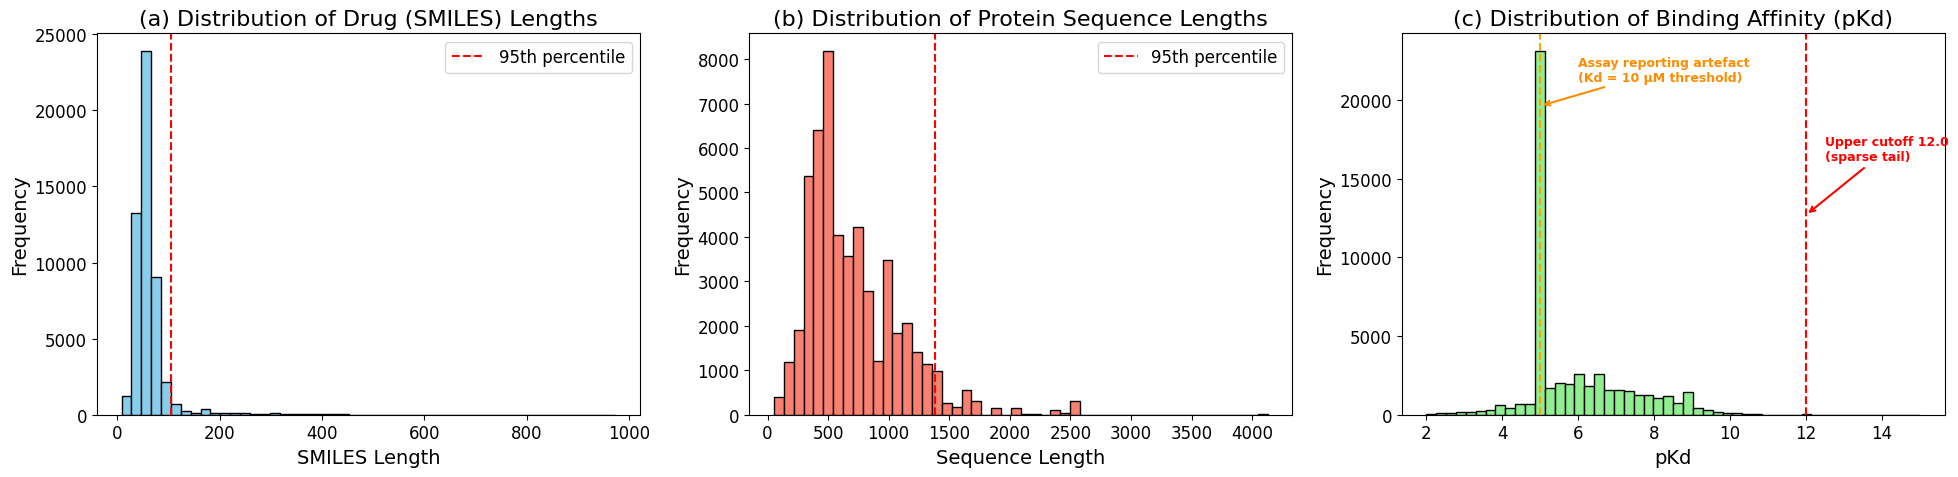

Drugs longer than 512 chars (ChemBERTa max): 0.10% of pairs

count    52272.000000
mean        63.205540
std         44.256831
min          8.000000
25%         46.000000
50%         56.000000
75%         66.000000
max        973.000000
Name: Drug, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Drug lengths - ChemBERTa truncates at 512 chars
drug_lens = df["Drug"].apply(len)
axes[0].hist(drug_lens, bins=50, color="skyblue", edgecolor="black")
axes[0].axvline(
    drug_lens.quantile(0.95),
    color="red",
    linestyle="dashed",
    linewidth=1.5,
    label="95th percentile",
)
axes[0].set_title("(a) Distribution of Drug (SMILES) Lengths")
axes[0].set_xlabel("SMILES Length")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Protein sequence lengths — ProteinBERT has no hard length limit
prot_lens = df["Target"].apply(len)
axes[1].hist(prot_lens, bins=50, color="salmon", edgecolor="black")
axes[1].axvline(
    prot_lens.quantile(0.95),
    color="red",
    linestyle="dashed",
    linewidth=1.5,
    label="95th percentile",
)
axes[1].set_title("(b) Distribution of Protein Sequence Lengths")
axes[1].set_xlabel("Sequence Length")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# pKd distribution
counts, edges, _ = axes[2].hist(
    df["pKd"], bins=50, color="lightgreen", edgecolor="black"
)

# Annotate the artefact spike at pKd = 5.0
axes[2].axvline(5.0, color="orange", linestyle="dashed", linewidth=1.5)
ymax = counts.max()
axes[2].annotate(
    "Assay reporting artefact\n(Kd = 10 μM threshold)",
    xy=(5.0, ymax * 0.85),
    xytext=(6.0, ymax * 0.92),
    fontsize=9,
    color="darkorange",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.5),
    ha="left",
)

# Annotate the upper cutoff at pKd = 12.0
axes[2].axvline(12.0, color="red", linestyle="dashed", linewidth=1.5)
axes[2].annotate(
    "Upper cutoff 12.0\n(sparse tail)",
    xy=(12.0, ymax * 0.55),
    xytext=(12.5, ymax * 0.70),
    fontsize=9,
    color="red",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    ha="left",
)

axes[2].set_title("(c) Distribution of Binding Affinity (pKd)")
axes[2].set_xlabel("pKd")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(
    f"Drugs longer than 512 chars (ChemBERTa max): {(drug_lens > 512).mean():.2%} of pairs"
)
print()
print(drug_lens.describe())


In [8]:
df_ranged_pKd = df[(df["pKd"] != 5.0) & (df["pKd"] <= 12.0)]
print(
    f"Pairs with pKd ≤ 12.0, pKd != 5.0: {(df_ranged_pKd.shape[0] / df.shape[0]):.2%} of total"
)


Pairs with pKd ≤ 12.0, pKd != 5.0: 57.54% of total


**Findings:**

- **Drug SMILES** — the vast majority are under 512 characters, which is the ChemBERTa tokenizer limit. Only 0.10% of pairs have drugs longer than 512. Rather than truncate (which could silently remove functionally important substructures of the molecule), we drop these pairs entirely.

- **Protein sequences** — most are under ~1024 residues. ProteinBERT handles arbitrary-length proteins (no hard limit), so no protein truncation is needed. This is one of the motivating reasons for choosing ProteinBERT over ESM-2 (which caps at 1022 tokens).

- **pKd distribution** — there is a pronounced artifact spike at exactly `pKd = 5.0`. We drop these as they are uninformative. We also cap at `pKd = 12.0` because the tail beyond this is sparse and dominated by a few very high-affinity outliers that would skew training.

This filtering step leaves us with 58% of the original data.

### 3.4 Drugs per protein distribution

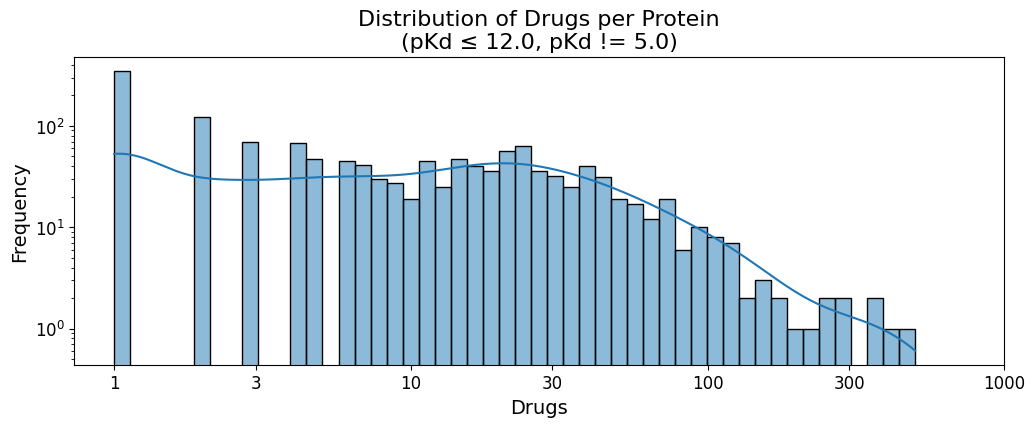

Fraction of proteins with ≥3 known binders (pKd ≤ 12.0, pKd != 5.0): 66.5%
Fraction of proteins with ≥5 known binders (pKd ≤ 12.0, pKd != 5.0): 56.8%
Fraction of proteins with ≥10 known binders (pKd ≤ 12.0, pKd != 5.0): 43.4%


In [9]:
drugs_per_protein = df_ranged_pKd.groupby("Target")["Drug"].nunique()

# Plot histogram of drugs per protein (log-log scale)
plt.figure(figsize=(12, 4))
sns.histplot(np.log10(drugs_per_protein), bins=50, kde=True)
plt.title("Distribution of Drugs per Protein\n(pKd ≤ 12.0, pKd != 5.0)")
plt.xlabel("Drugs")
plt.ylabel("Frequency")
plt.yscale("log")
# label x axis with unlogged ticks
ticks = [1, 3, 10, 30, 100, 300, 1000]
plt.xticks(np.log10(ticks), ticks)
plt.show()

# Print what fraction of proteins have ≥3, ≥5, ≥10 known binders
for n in [3, 5, 10]:
    frac = (drugs_per_protein >= n).mean()
    print(
        f"Fraction of proteins with ≥{n} known binders (pKd ≤ 12.0, pKd != 5.0): {frac:.1%}"
    )


**Finding:**

Most proteins have only a few known binders. This sparsity means that for most proteins, the model will have very limited per-protein supervision.

### 3.5 pKd coverage per protein

_Motivates: how much affinity diversity exists per protein — are rankings learnable?_

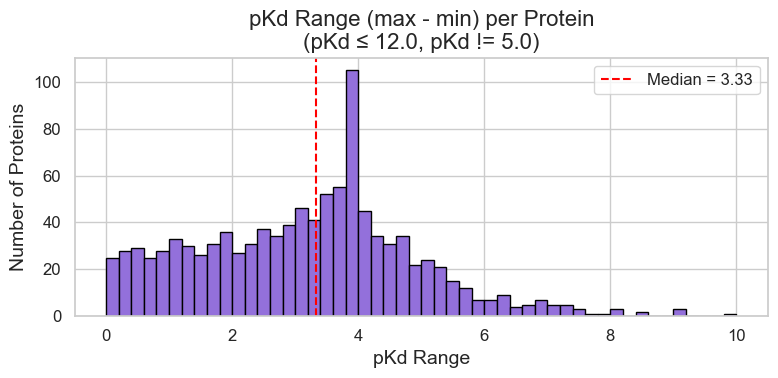

Proteins with ≥2 drugs: 1,059

Summary of pKd range per protein:
count    1059.000000
mean        3.170987
std         1.724750
min         0.000000
25%         1.845078
50%         3.334713
75%         4.142118
max        10.000000
Name: pKd, dtype: float64


In [ ]:
# Only consider proteins with >=2 known drugs (need at least 2 to compute a range)
proteins_multi = drugs_per_protein[drugs_per_protein >= 2].index
df_proteins_multi = df_ranged_pKd[df_ranged_pKd["Target"].isin(proteins_multi)]

pkd_range_per_protein = df_proteins_multi.groupby("Target")["pKd"].agg(
    lambda x: x.max() - x.min()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pkd_range_per_protein, bins=50, color="mediumpurple", edgecolor="black")
ax.axvline(
    pkd_range_per_protein.median(),
    color="red",
    linestyle="dashed",
    linewidth=1.5,
    label=f"Median = {pkd_range_per_protein.median():.2f}",
)
ax.set_title("pKd Range (max - min) per Protein\n(pKd ≤ 12.0, pKd != 5.0)")
ax.set_xlabel("pKd Range")
ax.set_ylabel("Number of Proteins")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Proteins with ≥2 drugs: {len(pkd_range_per_protein):,}")
print("\nSummary of pKd range per protein:")
print(pkd_range_per_protein.describe())


**Finding:**

This means that we have enough variance in pKd values for our models to learn from.

### 3.6 Unique Protein-Drug Pairs



In [ ]:
n_proteins = df["Target"].nunique()
n_drugs = df["Drug"].nunique()
avg_drugs = df.groupby("Target")["Drug"].nunique().mean()
print(f"Unique proteins: {n_proteins}")
print(f"Unique drugs: {n_drugs}")
print(f"Average drugs per protein: {avg_drugs:.1f}")


Unique proteins: 1413
Unique drugs: 10659
Average drugs per protein: 32.6


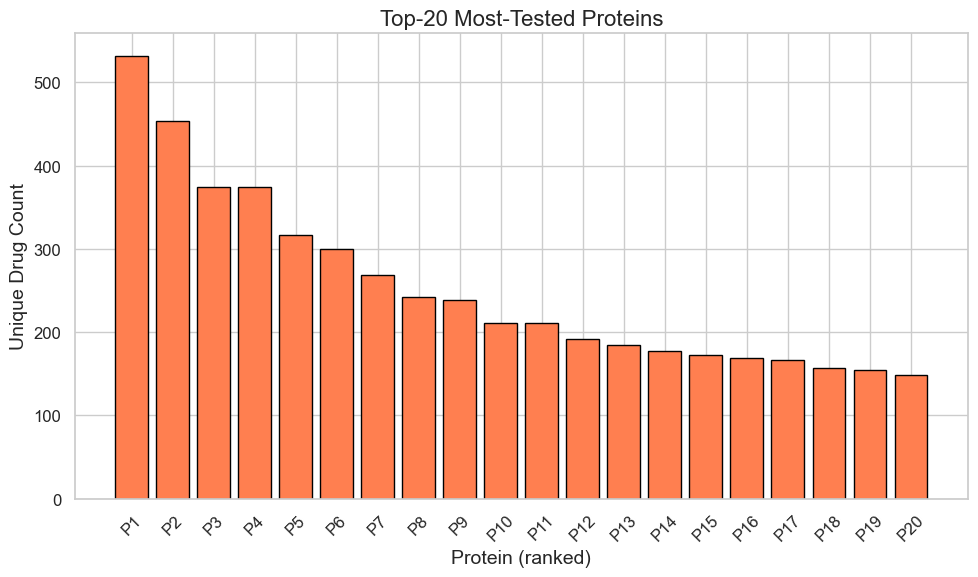

In [ ]:
top20 = df.groupby("Target")["Drug"].nunique().nlargest(20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(20), top20.values, color="coral", edgecolor="black")
ax.set_xticks(range(20))
ax.set_xticklabels([f"P{i + 1}" for i in range(20)], rotation=45)
ax.set_title("Top-20 Most-Tested Proteins")
ax.set_xlabel("Protein (ranked)")
ax.set_ylabel("Unique Drug Count")
plt.tight_layout()
plt.show()


In [ ]:
dupes = df.groupby(["Drug", "Target"])["Y"].nunique()
conflict_pairs = (dupes > 1).sum()
print(f"Drug-protein pairs with conflicting Y values: {conflict_pairs}")


Drug-protein pairs with conflicting Y values: 3488


**Findings:**
- The average of 32.6 drugs-protein is misleading because the top-20 hub proteins each have 150–530 binders while the majority have fewer than 5.
- This extreme imbalance means the model will be trained mostly on hub-protein chemistry, and generalization to rare proteins will be a challenge.

To characterise the spread of repeated `(Drug, Target)` measurements we plot the distribution of pKd standard deviation (SD) across replicate pairs. This informs our understanding of inter-lab noise, **but does not drive a filtering decision** — see the finding below for our rationale.

In [ ]:
def inspect_repeat_sds(data, stage_name):
    repeat_mask = data.duplicated(subset=["Drug", "Target"], keep=False)
    repeats = data[repeat_mask]

    if len(repeats) == 0:
        print(f"[{stage_name}] No repeat pairs.")
        return None

    sd = repeats.groupby(["Drug", "Target"])["pKd"].std(ddof=1).dropna()
    n_pairs = len(sd)
    print(f"[{stage_name}]")
    print(f"  Total rows:           {len(data):>8,}")
    print(f"  Rows in repeat pairs: {len(repeats):>8,}")
    print(f"  Unique repeat pairs:  {n_pairs:>8,}")
    print(f"  Median SD:            {sd.median():>8.3f}")
    print(f"  Mean SD:              {sd.mean():>8.3f}")
    for thr in [0.5, 1.0, 1.5, 2.0, 2.5]:
        n_drop = (sd > thr).sum()
        print(
            f"  SD > {thr}:  drop {n_drop:>5,} / {n_pairs:,} pairs ({n_drop / n_pairs:>5.1%})"
        )
    print()
    return sd


# Apply the same filters we'll use in Section 4, then look at repeat SDs
df_filt = df[(df["pKd"] != 5.0) & (df["pKd"] <= 12.0) & (df["Drug"].str.len() <= 512)]
sd_filt = inspect_repeat_sds(df_filt, "AFTER pKd != 5.0, pKd <= 12.0, SMILES <= 512")


[AFTER pKd != 5.0, pKd <= 12.0, SMILES <= 512]
  Total rows:             30,025
  Rows in repeat pairs:    7,195
  Unique repeat pairs:     2,370
  Median SD:               0.438
  Mean SD:                 0.601
  SD > 0.5:  drop 1,083 / 2,370 pairs (45.7%)
  SD > 1.0:  drop   453 / 2,370 pairs (19.1%)
  SD > 1.5:  drop   169 / 2,370 pairs ( 7.1%)
  SD > 2.0:  drop    89 / 2,370 pairs ( 3.8%)
  SD > 2.5:  drop    44 / 2,370 pairs ( 1.9%)



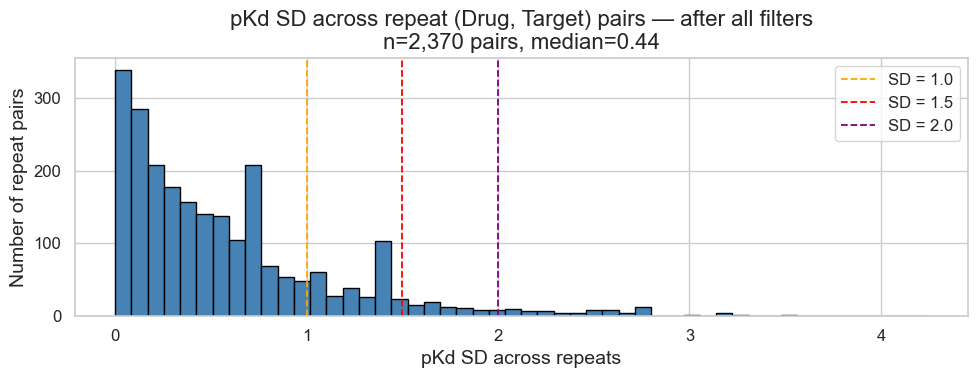

In [ ]:
# Visualize the SD distribution with threshold markers
if sd_filt is not None and len(sd_filt) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(sd_filt, bins=50, color="steelblue", edgecolor="black")
    for thr, color in [(1.0, "orange"), (1.5, "red"), (2.0, "purple")]:
        ax.axvline(thr, color=color, linestyle="--", linewidth=1.3, label=f"SD = {thr}")
    ax.set_title(
        f"pKd SD across repeat (Drug, Target) pairs — after all filters\n"
        f"n={len(sd_filt):,} pairs, median={sd_filt.median():.2f}"
    )
    ax.set_xlabel("pKd SD across repeats")
    ax.set_ylabel("Number of repeat pairs")
    ax.legend()
    plt.tight_layout()
    plt.show()


**Finding:** After filtering out the `pKd = 5.0` assay artifact and capping at 12.0, the remaining repeat-pair SD distribution reflects genuine inter-lab noise. The median SD is ~0.4–0.6 pKd units — labs typically agree to within a factor of ~2–4 in Kd. This sets a practical floor on model performance: no predictor can do better than the labels themselves.

**Decision — keep all observations separate:**

We initially considered two preprocessing steps for handling repeat measurements are (1) averaging replicates into a single consensus value and (2) dropping pairs whose SD exceeds a threshold. After discussion, we decided to avoid both for the following reasons:

- **Averaging collapses a random variable into a point estimate.** pKd is not a fixed property of a pair — it is a noisy measurement drawn from a distribution that reflects experimental conditions, assay variability, and genuine biological uncertainty. Averaging discards exactly the variance information we want the model to learn.
- **Dropping high-SD pairs discards useful signal.** High spread does not mean the measurements are wrong; it can reflect real assay sensitivity differences or biologically interesting edge cases. Removing these pairs introduces a selection bias toward artificially "clean" data.

We therefore retain **all individual observations** as separate training examples. The model is trained to predict the distribution of pKd values (via a probabilistic output head), so repeated measurements for the same pair provide direct supervision on the uncertainty. As a future experiment, we can run ablations with SD-based filtering and averaging to quantify the effect on held-out performance.

In [ ]:
df_filt = df[(df["pKd"] != 5.0) & (df["pKd"] <= 12.0) & (df["Drug"].str.len() <= 512)]
print("\nAFTER data cleaning: drop pKd == 5.0, cap pKd <= 12.0, SMILES <= 512")
print(
    f"  Percentage of pairs dropped: {100 * (1 - df_filt.shape[0] / df.shape[0]):.1f}%"
)
print(f"  Unique proteins: {df_filt['Target'].nunique():>7,}")
print(f"  Unique drugs:    {df_filt['Drug'].nunique():>7,}")
print(f"  Total pairs:     {df_filt.shape[0]:>7,}")
print(f"  Avg drugs/protein: {df_filt.shape[0] / df_filt['Target'].nunique():.1f}")



AFTER data cleaning: drop pKd == 5.0, cap pKd <= 12.0, SMILES <= 512
  Percentage of pairs dropped: 42.6%
  Unique proteins:   1,403
  Unique drugs:     10,527
  Total pairs:      30,025
  Avg drugs/protein: 21.4


### 3.7 Protein families, drug classes, and class imbalance

Protein family labels were assigned by querying the UniProt REST API for each `Target_ID` and applying keyword matching against the `PROTEIN_FAMILIES` dictionary below. Results are cached in `bindingdb_kd_with_proteinfamily.csv`.

**Class definition:** we keep all labeled families as their own categories. Proteins
with a missing (NaN) family label are bucketed into `"other"`.

In [ ]:
PROTEIN_FAMILIES = {
    "kinase": ["kinase"],
    "protease": ["protease", "peptidase"],
    "GPCR": [
        "gpcr",
        "adrenergic",
        "dopamine",
        "serotonin",
        "muscarinic",
        "histamine",
        "opioid",
    ],
    "nuclear receptor": ["nuclear receptor", "androgen", "estrogen", "glucocorticoid"],
    "ion channel": ["channel", "transporter"],
    "carbohydrase": ["glucosidase", "amylase", "glycosidase", "carbohydrase"],
    "oxidoreductase": ["oxidase", "reductase", "dehydrogenase", "peroxidase"],
    "phosphatase": ["phosphatase"],
    "other": [],
}
CACHE_PATH = "./data/uniprot_name_cache.csv"


def fetch_uniprot_info(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"
    response = requests.get(url)

    if response.status_code != 200:
        return None

    data = response.json()

    # Extract useful text fields
    protein_name = (
        data.get("proteinDescription", {})
        .get("recommendedName", {})
        .get("fullName", {})
        .get("value", "")
    )

    comments = []
    for c in data.get("comments", []):
        if "texts" in c:
            comments.extend([t["value"] for t in c["texts"]])

    text_blob = " ".join([protein_name] + comments).lower()
    return text_blob


def assign_protein_family(text):
    for family, keywords in PROTEIN_FAMILIES.items():
        for kw in keywords:
            if kw in text:
                return family
    return "other"


def load_cache():
    if os.path.exists(CACHE_PATH):
        return pd.read_csv(CACHE_PATH)
    return pd.DataFrame(columns=["uniprot_id", "text", "family"])


def save_cache(df):
    df.to_csv(CACHE_PATH, index=False)


def retrieve_and_append_pf(df):
    cache_df = load_cache()
    existing_ids = set(cache_df["uniprot_id"])

    unique_targets = df["Target_ID"].dropna().unique()
    missing_ids = [tid for tid in unique_targets if tid not in existing_ids]

    print(f"Querying {len(missing_ids)} new proteins...")

    new_rows = []

    for i, tid in enumerate(missing_ids):
        text = fetch_uniprot_info(tid)

        if text is None:
            family = "other"
        else:
            family = assign_protein_family(text)

        new_rows.append({"uniprot_id": tid, "text": text, "family": family})

        time.sleep(0.1)

        if i % 50 == 0:
            print(f"{i}/{len(missing_ids)} processed")

    if new_rows:
        new_df = pd.DataFrame(new_rows)
        cache_df = pd.concat([cache_df, new_df], ignore_index=True)
        save_cache(cache_df)

    df = df.merge(
        cache_df[["uniprot_id", "family"]],
        left_on="Target_ID",
        right_on="uniprot_id",
        how="left",
    )

    df = df.rename(columns={"family": "Protein_Family"})
    df = df.drop(columns=["uniprot_id"])

    return df


In [ ]:
Path("./data").mkdir(exist_ok=True)

pf_path = Path("./data/bindingdb_kd_with_proteinfamily.csv")
raw_path = Path("./data/bindingdb_kd.csv")

if pf_path.exists():
    df = pd.read_csv(pf_path)
    print("Loaded dataset WITH protein families from disk")
else:
    if raw_path.exists():
        df = pd.read_csv(raw_path)
        print("Loaded raw dataset from disk")
    else:
        data = DTI(name="BindingDB_Kd")
        df = data.get_data()
        df.to_csv(raw_path, index=False)
        print("Downloaded and saved raw dataset")

    print("Generating protein families...")
    df = retrieve_and_append_pf(df)
    df.to_csv(pf_path, index=False)
    print("Saved dataset WITH protein families")

print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nBasic stats:")
print(df.describe())


Loaded dataset WITH protein families from disk

Shape: (52274, 7)
Columns: ['Drug_ID', 'Drug', 'Target_ID', 'Target', 'Y', 'Protein_Family', 'selfies_len']

Basic stats:
            Drug_ID             Y   selfies_len
count  5.227400e+04  5.227400e+04  52274.000000
mean   2.587647e+07  4.353189e+04     57.002716
std    3.469676e+07  4.102312e+05     29.863350
min    5.100000e+01  0.000000e+00      7.000000
25%    5.328940e+06  2.200000e+02     43.000000
50%    1.107117e+07  9.800000e+03     52.000000
75%    2.518873e+07  1.000000e+04     63.000000
max    1.388059e+08  1.000000e+07    659.000000


Filled 3,215 missing Protein_Family labels with 'other'



Protein family breakdown:
Protein_Family
kinase              16952
GPCR                 6523
other                5499
ion channel           400
protease              329
oxidoreductase        264
nuclear receptor       31
phosphatase            27
Name: count, dtype: int64

Target
MADQLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAELQDMINEVDADGNGTIDFPEFLTMMARKMKDTDSEEEIREAFRVFDKDGNGYISAAELRHVMTNLGEKLTDEEVDEMIREADIDGDGQVNYEEFVQMMTAK    2
Name: Protein_Family, dtype: int64


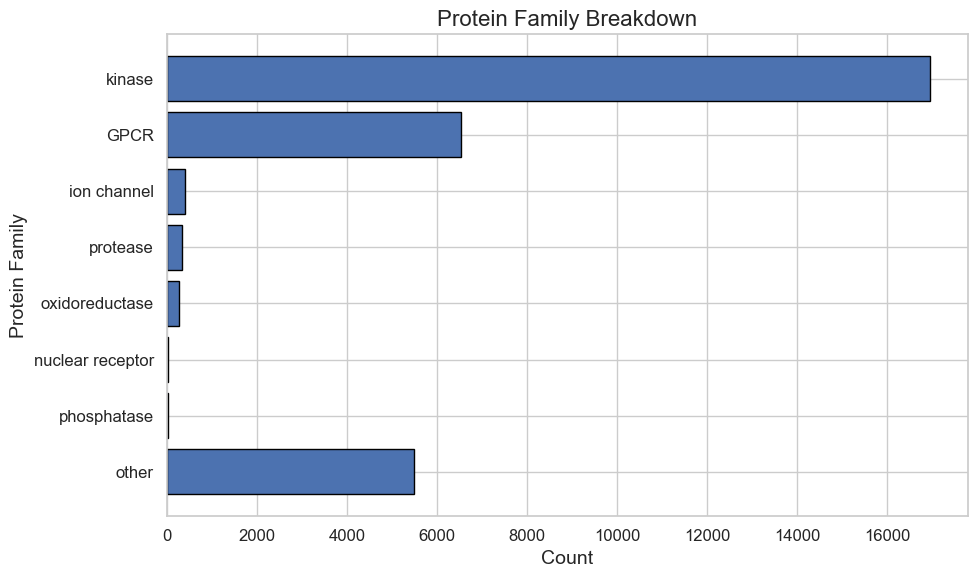

In [ ]:
# Fill missing Protein_Family with "other" so the plots and stratification are consistent.
df_families = df_filt.copy()

n_missing = df_families["Protein_Family"].isna().sum()
df_families["Protein_Family"] = df_families["Protein_Family"].fillna("other")
print(f"Filled {n_missing:,} missing Protein_Family labels with 'other'")
print()
print("Protein family breakdown:")
print(df_families["Protein_Family"].value_counts())
print()

# Sanity: ensure each protein is in exactly one family (post-fillna, no NaN)
protein_family_counts = df_families.groupby("Target")["Protein_Family"].nunique()
conflicting_proteins = protein_family_counts[protein_family_counts > 1]
if len(conflicting_proteins) > 0:
    print(
        f"Warning: {len(conflicting_proteins)} proteins have conflicting family annotations"
    )
    print(conflicting_proteins.head())
else:
    print("All proteins map to a single family (no conflicts).")

family_counts = df_families["Protein_Family"].value_counts()

if "other" in family_counts.index:
    other_count = family_counts.pop("other")
    family_counts.loc["other"] = other_count

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(family_counts.index, family_counts.values, edgecolor="black")
ax.set_title("Protein Family Breakdown")
ax.set_xlabel("Count")
ax.set_ylabel("Protein Family")
ax.invert_yaxis()

plt.tight_layout()
plt.show()


**Finding — class imbalance:** The dataset is heavily skewed toward kinases, followed by GPCRs. This reflects the commercial focus of pharmaceutical research, where kinases are the most heavily screened class.

**Implication for modeling:**
- We mitigate this by using `StratifiedShuffleSplit` on protein family (on top of per protein split) in Section 4. Rare families are grouped into a coarse "other" bucket for stratification purposes (so each split gets proportional representation), while the fine-grained label is preserved for per-family metric reporting at evaluation time.

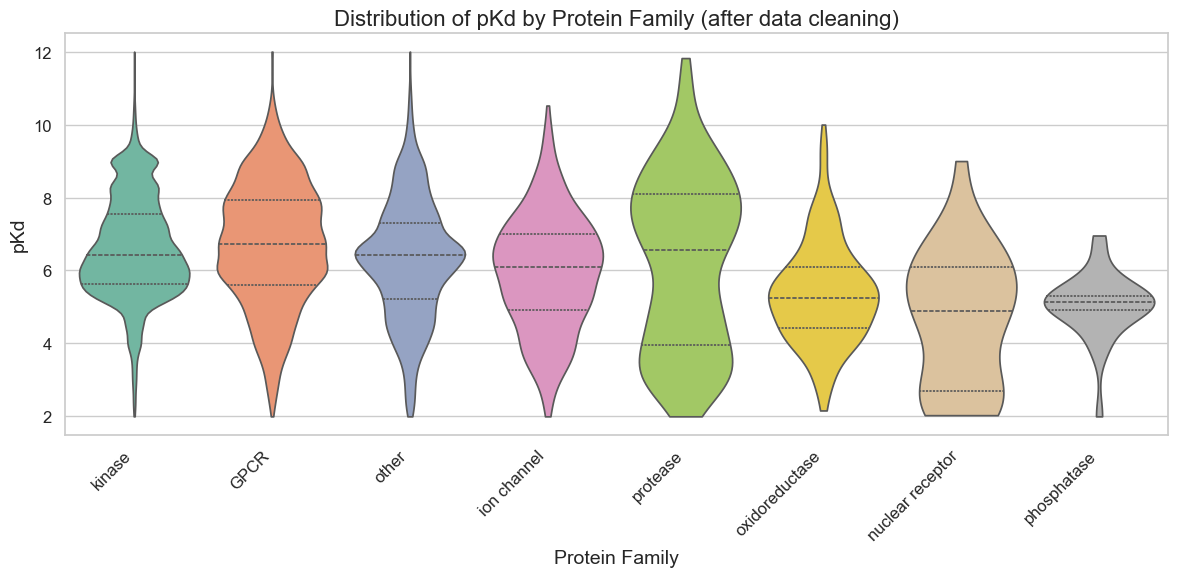

In [ ]:
# Violin plot: distribution of pKd by protein family
plt.figure(figsize=(12, 6))
order = df_families["Protein_Family"].value_counts().index.tolist()
sns.violinplot(
    x="Protein_Family",
    y="pKd",
    data=df_families,
    order=order,
    inner="quartile",
    palette="Set2",
    cut=0,
)
plt.title("Distribution of pKd by Protein Family (after data cleaning)")
plt.xlabel("Protein Family")
plt.ylabel("pKd")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


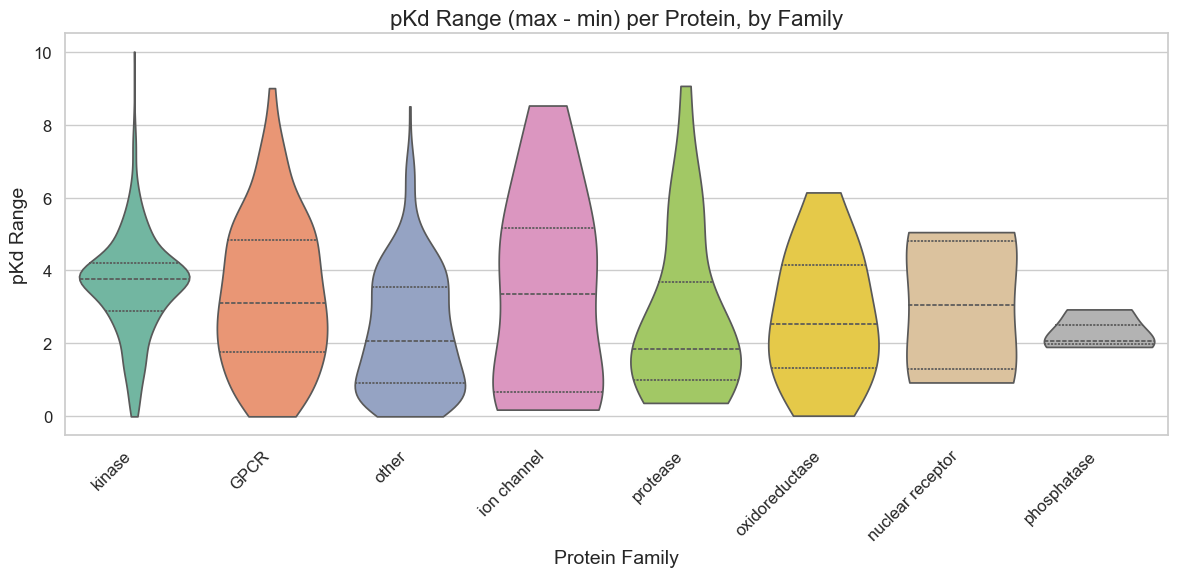

In [ ]:
# Violin plot: pKd range (max - min) per protein, grouped by family
# Drop proteins with only 1 measurement (range would trivially be 0)
df_multi_drug = df_families.groupby(["Target", "Protein_Family"]).filter(
    lambda x: len(x) > 1
)

pkd_range_per_protein_family = (
    df_multi_drug.groupby(["Target", "Protein_Family"])["pKd"]
    .agg(lambda x: x.max() - x.min())
    .reset_index(name="pKd_range")
)

plt.figure(figsize=(12, 6))
sns.violinplot(
    x="Protein_Family",
    y="pKd_range",
    data=pkd_range_per_protein_family,
    order=order,
    inner="quartile",
    palette="Set2",
    cut=0,
)
plt.title("pKd Range (max - min) per Protein, by Family")
plt.xlabel("Protein Family")
plt.ylabel("pKd Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Finding:**

From these 2 graphs, there are differences in protein family distributions of pKd, and therefore providing the model with the class information might be helpful for prediction. None of the classes seem defunct, so we can keep all of them for modelling.

## 4. Preprocessing

Each filtering step below is motivated by a specific EDA finding. The preprocessing
pipeline is:

1. Drop exact duplicate rows `(Drug, Target, Y)`
2. Drop the `pKd == 5.0` assay artifact and cap at `pKd <= 12.0` (keeps weaker binders below 5.0)
3. Drop drugs with SMILES > 512 characters (ChemBERTa limit — we drop rather than truncate)
4. **Keep ALL repeat `(Drug, Target)` measurements** — no SD-based filtering or averaging; the goal is to learn the pKd distribution over repeated measurements
5. No protein truncation (ProteinBERT handles arbitrary length)
6. Stratified 70/15/15 split by protein identity, stratified by coarse protein family

In [ ]:
PKD_ARTEFACT = 5.0  # drop pairs with pKd == exactly this (Kd = 10 uM assay ceiling)
PKD_MAX = 12.0  # inclusive upper cap — drops sparse high-affinity tail
MAX_SMILES_LEN = 512  # ChemBERTa tokenizer hard limit


In [ ]:
# Reload from disk so re-running this section starts from a clean raw df
df_raw = (
    pd.read_csv("./data/bindingdb_kd_with_proteinfamily.csv")
    if Path("./data/bindingdb_kd_with_proteinfamily.csv").exists()
    else pd.read_csv("./data/bindingdb_kd.csv")
)

n0 = len(df_raw)
steps = [("Raw dataset", n0)]

# 0. Drop Y == 0 (would produce infinite pKd) and compute pKd
df_raw = df_raw[df_raw["Y"] != 0].copy()
df_raw["pKd"] = -np.log10(df_raw["Y"] / 1e9)
steps.append(("Drop Y == 0", len(df_raw)))

# 0b. Fill missing Protein_Family with 'other' (the NaN-only definition)
if "Protein_Family" in df_raw.columns:
    df_raw["Protein_Family"] = df_raw["Protein_Family"].fillna("other")

# 1. Drop exact duplicate rows
df_step = df_raw.drop_duplicates(subset=["Drug", "Target", "Y"]).copy()
steps.append(("Drop exact duplicate rows", len(df_step)))

# 2. pKd filter — drop the exact 5.0 assay artifact and cap at PKD_MAX
df_step = df_step[(df_step["pKd"] != PKD_ARTEFACT) & (df_step["pKd"] <= PKD_MAX)].copy()
steps.append((f"Drop pKd == {PKD_ARTEFACT} and cap at pKd <= {PKD_MAX}", len(df_step)))

# 3. SMILES length filter
df_step = df_step[df_step["Drug"].str.len() <= MAX_SMILES_LEN].copy()
steps.append((f"SMILES <= {MAX_SMILES_LEN} chars", len(df_step)))

# 4. Keep ALL repeat (Drug, Target) measurements — no SD filtering or averaging.
#    Retaining all replicates lets the model learn the pKd distribution; the
#    spread of repeated measurements reflects genuine inter-lab noise.
steps.append(("Keep all repeat measurements (learn pKd distribution)", len(df_step)))

# 5. No protein truncation (ProteinBERT handles arbitrary length)
steps.append(("No protein truncation (ProteinBERT)", len(df_step)))

# 6. Add length convenience columns
df_step["Drug_len"] = df_step["Drug"].str.len()
df_step["Target_len"] = df_step["Target"].str.len()

df_clean = df_step.reset_index(drop=True)

print("=== Preprocessing Summary ===")
summary = pd.DataFrame(steps, columns=["Step", "Pairs"])
summary["% of raw"] = (summary["Pairs"] / n0 * 100).round(1)
print(summary.to_string(index=False))
print(f"\nFinal clean dataset: {len(df_clean):,} pairs")
print(f"  Unique proteins: {df_clean['Target'].nunique():,}")
print(f"  Unique drugs:    {df_clean['Drug'].nunique():,}")
print(
    f"  Repeat (Drug, Target) pairs: {df_clean.duplicated(subset=['Drug', 'Target']).sum():,}"
)


=== Preprocessing Summary ===
                                                 Step  Pairs  % of raw
                                          Raw dataset  52274     100.0
                                          Drop Y == 0  52272     100.0
                            Drop exact duplicate rows  52272     100.0
               Drop pKd == 5.0 and cap at pKd <= 12.0  30076      57.5
                                  SMILES <= 512 chars  30025      57.4
Keep all repeat measurements (learn pKd distribution)  30025      57.4
                  No protein truncation (ProteinBERT)  30025      57.4

Final clean dataset: 30,025 pairs
  Unique proteins: 1,403
  Unique drugs:    10,527
  Repeat (Drug, Target) pairs: 4,825


### 4.1 Train / validation / test split — stratified by protein family

In [ ]:
# Stratified 70/15/15 split by protein identity, with stratification on protein family.
# "other" is defined as NaN only — all labeled families (including rare ones) keep
# their own stratum. This matches the NaN-only definition used in cell 34.
def coarse_family(fam):
    return "other" if pd.isna(fam) else fam


# Build one row per unique protein with its family label
if "Protein_Family" in df_clean.columns:
    protein_fam = (
        df_clean.groupby("Target")["Protein_Family"]
        .agg(lambda s: s.mode().iat[0] if len(s.mode()) else "other")
        .reset_index()
    )
    protein_fam["stratum"] = protein_fam["Protein_Family"].apply(coarse_family)
else:
    protein_fam = pd.DataFrame({"Target": df_clean["Target"].unique()})
    protein_fam["stratum"] = "other"

print("Family distribution across unique proteins:")
print(protein_fam["stratum"].value_counts())
print()

# Stratified 70/15/15 split at the PROTEIN level
proteins = protein_fam["Target"].values
strata = protein_fam["stratum"].values

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(sss1.split(proteins, strata))

sss2 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15 / 0.85,  # 15/85 of what remains -> 15% of original
    random_state=SEED,
)
train_idx, val_idx = next(sss2.split(proteins[trainval_idx], strata[trainval_idx]))

test_proteins = set(proteins[test_idx])
val_proteins = set(proteins[trainval_idx][val_idx])
train_proteins = set(proteins[trainval_idx][train_idx])


def assign_split(target):
    if target in test_proteins:
        return "test"
    if target in val_proteins:
        return "val"
    return "train"


df_clean["split"] = df_clean["Target"].apply(assign_split)

# Sanity check: no protein should appear in more than one split (no leakage)
assert not (train_proteins & val_proteins), "LEAKAGE: train ∩ val"
assert not (train_proteins & test_proteins), "LEAKAGE: train ∩ test"
assert not (val_proteins & test_proteins), "LEAKAGE: val   ∩ test"
print("Leakage check passed: no protein appears in more than one split.")
print()

split_counts = df_clean["split"].value_counts()
print("Split sizes (pairs):")
for s in ["train", "val", "test"]:
    n_pairs = split_counts.get(s, 0)
    n_prot = df_clean[df_clean["split"] == s]["Target"].nunique()
    print(
        f"  {s:5s}: {n_pairs:>7,} pairs ({n_pairs / len(df_clean):5.1%})  |  {n_prot:,} proteins"
    )


Family distribution across unique proteins:
stratum
other               523
kinase              523
GPCR                265
protease             34
ion channel          27
oxidoreductase       21
nuclear receptor      6
phosphatase           4
Name: count, dtype: int64

Leakage check passed: no protein appears in more than one split.

Split sizes (pairs):
  train:  22,750 pairs (75.8%)  |  981 proteins
  val  :   3,407 pairs (11.3%)  |  211 proteins
  test :   3,868 pairs (12.9%)  |  211 proteins


In [ ]:
# Save the full clean dataset and one CSV per split.
# Downstream code can load these directly without re-running preprocessing.
Path("./data/splits").mkdir(exist_ok=True)

df_clean.to_csv("./data/splits/df_clean.csv", index=False)
for split in ["train", "val", "test"]:
    df_clean[df_clean["split"] == split].to_csv(
        f"./data/splits/{split}.csv", index=False
    )

print("Saved to ./data/splits/")
for name in ["train", "val", "test", "df_clean"]:
    rows = len(df_clean) if name == "df_clean" else (df_clean["split"] == name).sum()
    print(f"  {name}.csv  {rows:>7,} rows")


Saved to ./data/splits/
  train.csv   22,750 rows
  val.csv    3,407 rows
  test.csv    3,868 rows
  df_clean.csv   30,025 rows


### 4.2 Split-bias sanity checks

There are obvious differences in the distribution of various metrics between splits, providing further evidence in support of our split approach.

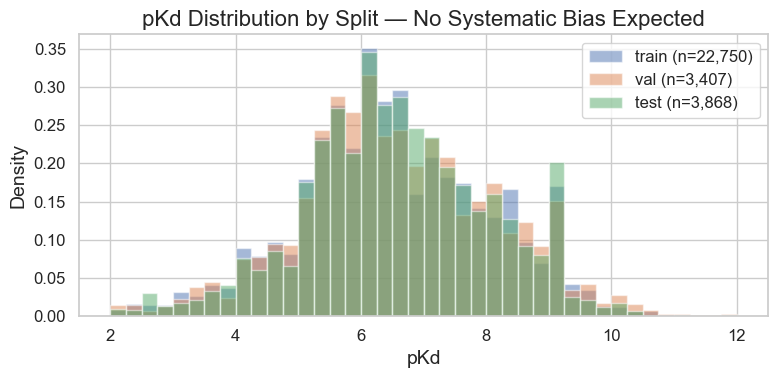

In [ ]:
# pKd distribution per split
fig, ax = plt.subplots(figsize=(8, 4))
for s in ["train", "val", "test"]:
    vals = df_clean[df_clean["split"] == s]["pKd"]
    ax.hist(vals, bins=40, alpha=0.5, density=True, label=f"{s} (n={len(vals):,})")
ax.set_title("pKd Distribution by Split — No Systematic Bias Expected")
ax.set_xlabel("pKd")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


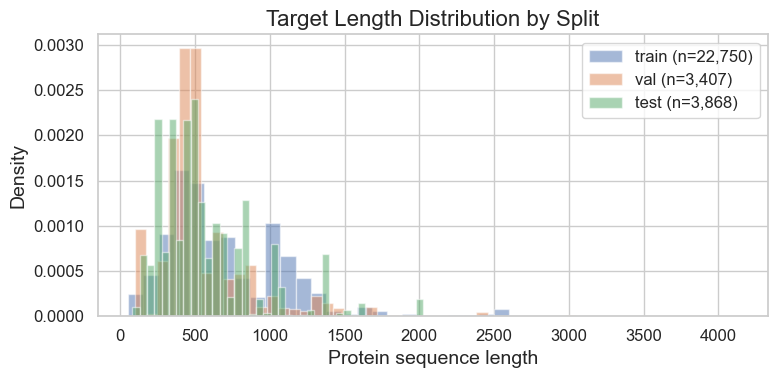

In [ ]:
# Target length distribution per split
fig, ax = plt.subplots(figsize=(8, 4))
for s in ["train", "val", "test"]:
    vals = df_clean[df_clean["split"] == s]["Target_len"]
    ax.hist(vals, bins=40, alpha=0.5, density=True, label=f"{s} (n={len(vals):,})")
ax.set_title("Target Length Distribution by Split")
ax.set_xlabel("Protein sequence length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


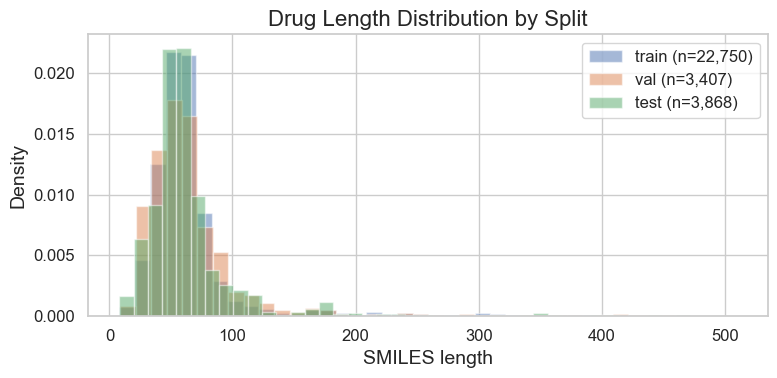

In [ ]:
# Drug length distribution per split
fig, ax = plt.subplots(figsize=(8, 4))
for s in ["train", "val", "test"]:
    vals = df_clean[df_clean["split"] == s]["Drug_len"]
    ax.hist(vals, bins=40, alpha=0.5, density=True, label=f"{s} (n={len(vals):,})")
ax.set_title("Drug Length Distribution by Split")
ax.set_xlabel("SMILES length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


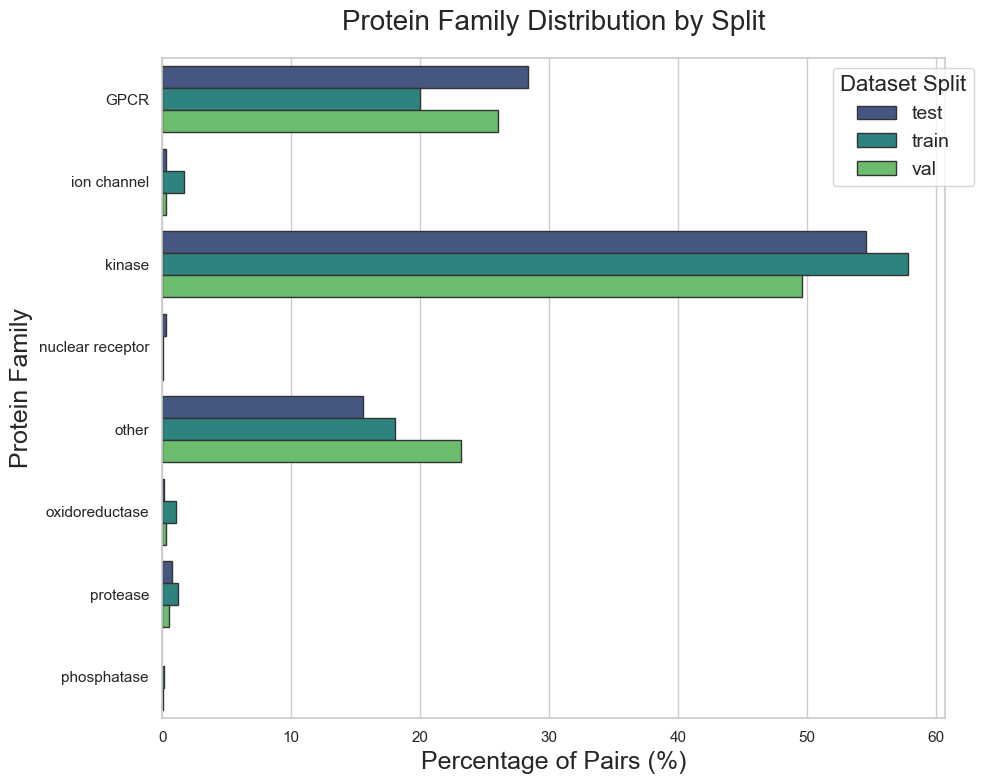

In [ ]:
# Protein family distribution per split
df_plot = df_clean.assign(coarse=df_clean["Protein_Family"].apply(coarse_family))
fam_counts = df_plot.groupby(["split", "coarse"]).size().reset_index(name="counts")

total_counts = fam_counts.groupby("split")["counts"].transform("sum")
fam_counts["percentage"] = (fam_counts["counts"] / total_counts) * 100

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=fam_counts,
    y="coarse",
    x="percentage",
    hue="split",
    palette="viridis",
    edgecolor="0.2",
)

plt.title("Protein Family Distribution by Split", fontsize=20, pad=20)
plt.xlabel("Percentage of Pairs (%)", fontsize=18)
plt.ylabel("Protein Family", fontsize=18)
plt.legend(
    title="Dataset Split", fontsize=14, title_fontsize=16, bbox_to_anchor=(1.05, 1)
)
plt.tight_layout()
plt.show()


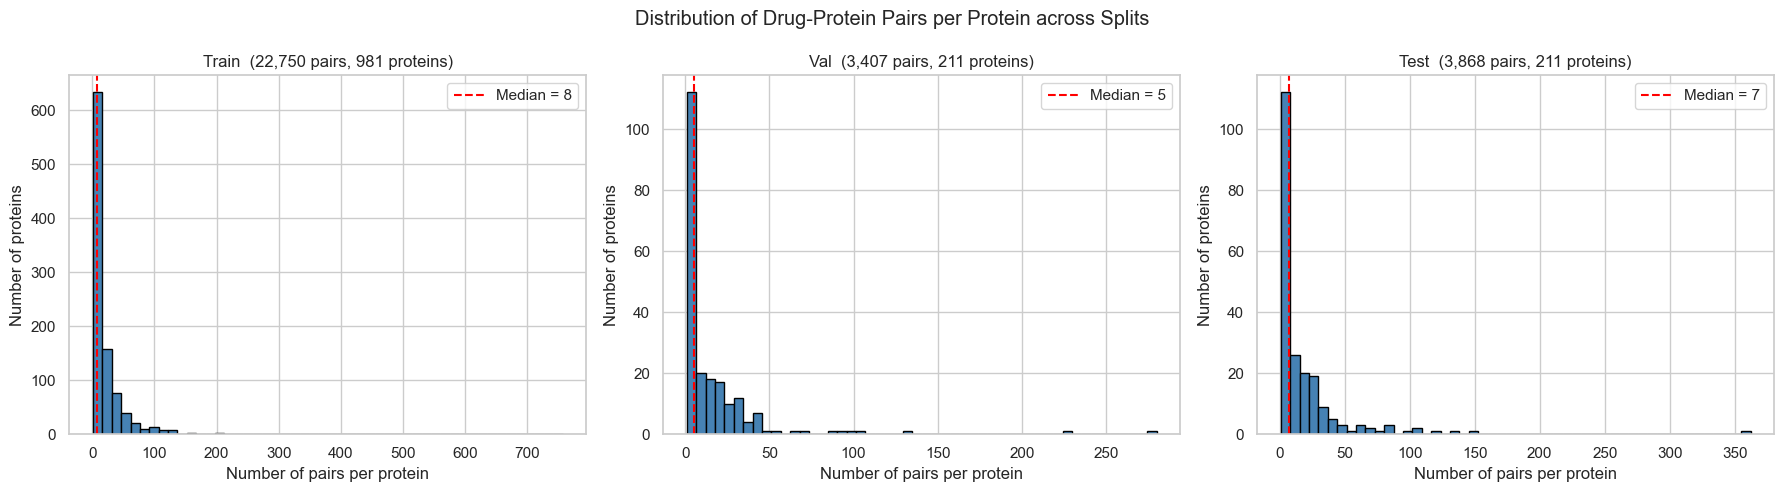

Split      Proteins    Min   Median     Mean    Max  ≥10 pairs
----------------------------------------------------------
Train           981      1      8.0     23.2    757        449
Val             211      1      5.0     16.1    280         88
Test            211      1      7.0     18.3    362         99


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution of Drug-Protein Pairs per Protein across Splits")

for ax, split in zip(axes, ["train", "val", "test"]):
    counts = df_clean[df_clean["split"] == split].groupby("Target").size()
    ax.hist(counts, bins=50, color="steelblue", edgecolor="black")
    ax.axvline(
        counts.median(),
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Median = {counts.median():.0f}",
    )
    ax.set_title(
        f"{split.capitalize()}  ({counts.sum():,} pairs, {len(counts):,} proteins)"
    )
    ax.set_xlabel("Number of pairs per protein")
    ax.set_ylabel("Number of proteins")
    ax.legend()

plt.tight_layout()
plt.show()

print(
    f"{'Split':<8} {'Proteins':>10} {'Min':>6} {'Median':>8} {'Mean':>8} {'Max':>6} {'≥10 pairs':>10}"
)
print("-" * 58)
for split in ["train", "val", "test"]:
    c = df_clean[df_clean["split"] == split].groupby("Target").size()
    print(
        f"{split.capitalize():<8} {len(c):>10,} {c.min():>6} {c.median():>8.1f} "
        f"{c.mean():>8.1f} {c.max():>6} {(c >= 10).sum():>10,}"
    )


## 5. Summary of EDA and Preprocessing Findings

The dataset was cleaned to improve physical plausibility, measurement consistency, and model compatibility.

Entries with `Kd = 0.0` were removed before transforming affinities to `pKd`. The `pKd = 5.0` assay artifact was excluded, and entries with `pKd > 12.0` were removed as physically implausible. Compounds with SMILES strings longer than 512 characters were dropped to stay within the ChemBERTa input limit. **All repeated `(Drug, Target)` measurements are retained** — no SD-based filtering and no averaging — so the model can learn the full distribution of pKd values including inter-lab noise. The final train/validation/test split was performed at the protein level with stratification by family to reduce leakage and preserve class balance.

A key data finding is that the dataset is strongly imbalanced across protein families. Kinases dominate the data, followed by GPCRs. Missing family labels were reassigned to `other`. The strong family imbalance should be kept in mind when interpreting model performance.

## 6. Encoders — ProteinBERT & ChemBERTa

| Encoder | Input | Output dim | Max length | Frozen |
|---|---|---|---|---|
| ProteinBERT (`Rostlab/prot_bert_bfd`) | Amino acid sequence | 1024 | Unlimited | Yes |
| ChemBERTa (`DeepChem/ChemBERTa-100M-MLM`) | SMILES | 768 | 512 tokens | Yes |

Both encoders are used **frozen**. Embeddings are pre-computed once for all unique drugs and proteins in `df_clean` — covering train, val, and test splits — and cached to disk. No split leakage: embeddings contain only sequence information, no affinity labels.

Two versions are saved for each encoder:
- **Full** `(seq_len, hidden_dim)` — per-token embeddings, padding stripped. We can extract the [CLS] token for a global representation, or use the full sequence for cross-attention.
- **Pooled** `(hidden_dim,)` — mean of non-padding token embeddings. Optional for downstream experiments.

In [ ]:
CHEMBERTA_MODEL = "DeepChem/ChemBERTa-100M-MLM"
PROTEINBERT_MODEL = "Rostlab/prot_bert_bfd"

_encoders_cache = {}


def load_encoders():
    if _encoders_cache:
        return _encoders_cache

    transformers.logging.set_verbosity_error()

    chem_tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_MODEL)
    chem_model = AutoModel.from_pretrained(CHEMBERTA_MODEL).to(DEVICE).eval()
    prot_tokenizer = AutoTokenizer.from_pretrained(PROTEINBERT_MODEL)
    prot_model = AutoModel.from_pretrained(PROTEINBERT_MODEL).to(DEVICE).eval()
    transformers.logging.set_verbosity_warning()

    _encoders_cache.update(
        {
            "chem_tokenizer": chem_tokenizer,
            "chem_model": chem_model,
            "prot_tokenizer": prot_tokenizer,
            "prot_model": prot_model,
            "DRUG_DIM": chem_model.config.hidden_size,
            "PROT_DIM": prot_model.config.hidden_size,
        }
    )

    print(f"ChemBERTa hidden dim: {_encoders_cache['DRUG_DIM']}")
    print(f"ProteinBERT hidden dim: {_encoders_cache['PROT_DIM']}")

    return _encoders_cache


def mean_pool(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
    return (hidden_states * mask).sum(1) / mask.sum(1).clamp(min=1e-9)


In [ ]:
def mean_pool(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
    return (hidden_states * mask).sum(1) / mask.sum(1).clamp(min=1e-9)


In [ ]:
DRUG_POOLED_PATH = Path("./data/drug_emb_pooled.pt")
DRUG_FULL_PATH = Path("./data/drug_emb_full.pt")

if DRUG_POOLED_PATH.exists() and DRUG_FULL_PATH.exists():
    drug_emb_pooled = torch.load(DRUG_POOLED_PATH, weights_only=True)
    drug_emb_full = torch.load(DRUG_FULL_PATH, weights_only=True)
    print(f"Loaded drug embeddings from cache ({len(drug_emb_pooled):,} drugs)")
else:
    e = load_encoders()
    chem_tokenizer, chem_model, DRUG_DIM = (
        e["chem_tokenizer"],
        e["chem_model"],
        e["DRUG_DIM"],
    )

    unique_drugs = df_clean["Drug"].unique().tolist()
    print(f"Encoding {len(unique_drugs):,} unique drugs with ChemBERTa...")
    drug_emb_pooled, drug_emb_full = {}, {}
    BATCH = 64
    with torch.no_grad():
        for i in range(0, len(unique_drugs), BATCH):
            batch = unique_drugs[i : i + BATCH]

            # Tokenize
            enc = chem_tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=512,
            ).to(DEVICE)

            # Create embeddings
            out = chem_model(**enc).last_hidden_state  # Full embedding (B, L, 384)
            pooled = mean_pool(out, enc["attention_mask"])  # Pooled embedding (B, 384)
            for j, smi in enumerate(batch):
                drug_emb_pooled[smi] = pooled[j].cpu()
                L = enc["attention_mask"][j].sum().item()
                drug_emb_full[smi] = out[j, :L, :].cpu()  # strip padding

            if (i // BATCH) % 20 == 0:
                print(f"{i + len(batch):>6,} / {len(unique_drugs):,}")

    torch.save(drug_emb_pooled, DRUG_POOLED_PATH)
    torch.save(drug_emb_full, DRUG_FULL_PATH)
    print(f"Saved to {DRUG_POOLED_PATH} and {DRUG_FULL_PATH}")

s = df_clean["Drug"].iloc[0]
print(f"Sample drug pooled: {drug_emb_pooled[s].shape}")
print(f"Sample drug full: {drug_emb_full[s].shape}")


Loaded drug embeddings from cache (10,527 drugs)
Sample drug pooled: torch.Size([768])
Sample drug full: torch.Size([29, 768])


In [ ]:
PROT_POOLED_PATH = Path("./data/protein_emb_pooled.pt")
PROT_FULL_PATH = Path("./data/protein_emb_full.pt")

if PROT_POOLED_PATH.exists() and PROT_FULL_PATH.exists():
    prot_emb_pooled = torch.load(PROT_POOLED_PATH, weights_only=True)
    prot_emb_full = torch.load(PROT_FULL_PATH, weights_only=True)
    print(f"Loaded protein embeddings from cache ({len(prot_emb_pooled):,} proteins)")
else:
    enc = load_encoders()
    prot_tokenizer, prot_model, PROT_DIM = (
        e["prot_tokenizer"],
        e["prot_model"],
        e["PROT_DIM"],
    )

    unique_prots = df_clean["Target"].unique().tolist()
    print(f"Encoding {len(unique_prots):,} unique proteins with ProteinBERT...")
    prot_emb_pooled, prot_emb_full = {}, {}
    BATCH = 8  # small batch — protein sequences are long
    with torch.no_grad():
        for i in range(0, len(unique_prots), BATCH):
            batch = unique_prots[i : i + BATCH]
            # Rostlab/prot_bert requires space-separated amino acids
            batch_spaced = [" ".join(seq) for seq in batch]

            # Tokenize
            enc = prot_tokenizer(
                batch_spaced, return_tensors="pt", padding=True, truncation=False
            ).to(DEVICE)  # ProteinBERT handles arbitrary length

            # Embeddings
            out = prot_model(**enc).last_hidden_state  # Full embedding (B, L, 1024)
            pooled = mean_pool(out, enc["attention_mask"])  # Pooled embedding (B, 1024)

            for j, seq in enumerate(batch):
                prot_emb_pooled[seq] = pooled[j].cpu()
                L = enc["attention_mask"][j].sum().item()
                prot_emb_full[seq] = out[j, :L, :].cpu()  # strip padding

            if (i // BATCH) % 20 == 0:
                print(f" {i + len(batch):>5,} / {len(unique_prots):,}")
    torch.save(prot_emb_pooled, PROT_POOLED_PATH)
    torch.save(prot_emb_full, PROT_FULL_PATH)
    print(f"Saved to {PROT_POOLED_PATH} and {PROT_FULL_PATH}")

s = df_clean["Target"].iloc[0]
print(f"Sample protein pooled: {prot_emb_pooled[s].shape}")
print(f"Sample protein full: {prot_emb_full[s].shape}")


Loaded protein embeddings from cache (1,403 proteins)
Sample protein pooled: torch.Size([1024])
Sample protein full: torch.Size([262, 1024])


In [ ]:
# Verify every drug and protein in every split has a cached embedding
print(f"Coverage across splits:")
print(
    f"  {'Split':<8}  {'Drugs':>8}  {'Drug cov':>10}  {'Proteins':>10}  {'Prot cov':>10}"
)
print("  " + "-" * 55)
for split in ["train", "val", "test"]:
    sub = df_clean[df_clean["split"] == split]
    drugs = sub["Drug"].unique()
    prots = sub["Target"].unique()
    dc = sum(d in drug_emb_pooled for d in drugs) / len(drugs)
    pc = sum(p in prot_emb_pooled for p in prots) / len(prots)
    print(f"  {split:<8}  {len(drugs):>8,}  {dc:>9.1%}  {len(prots):>10,}  {pc:>9.1%}")


Coverage across splits:
  Split        Drugs    Drug cov    Proteins    Prot cov
  -------------------------------------------------------
  train        8,451     100.0%         981     100.0%
  val          1,716     100.0%         211     100.0%
  test         1,961     100.0%         211     100.0%


In [ ]:
drug_emb_cls = {smi: emb[0, :] for smi, emb in drug_emb_full.items()}  # (768,)
prot_emb_cls = {seq: emb[0, :] for seq, emb in prot_emb_full.items()}  # (1024,)
torch.save(drug_emb_cls, "./data/drug_emb_cls.pt")
torch.save(prot_emb_cls, "./data/protein_emb_cls.pt")

s_drug = next(iter(drug_emb_cls))
s_prot = next(iter(prot_emb_cls))
print(f"Drug CLS shape:    {drug_emb_cls[s_drug].shape}")  # torch.Size([768])
print(f"Protein CLS shape: {prot_emb_cls[s_prot].shape}")  # torch.Size([1024])
print(f"Saved {len(drug_emb_cls):,} drug CLS vectors")
print(f"Saved {len(prot_emb_cls):,} protein CLS vectors")


Drug CLS shape:    torch.Size([768])
Protein CLS shape: torch.Size([1024])
Saved 10,527 drug CLS vectors
Saved 1,403 protein CLS vectors


## 7. Training Infrastructure
Here we load in the CSVs and cached embeddings and define a few boiler plate classes and functions:
- AffinityDataset — takes in a dataframe and drug/protein embedding caches, returns paired embeddings and pKd labels
- collate_padded — collate function for DataLoader to handle variable-length sequences (for cross-attention model)
- make_weighted_sampler - helper function to resample the training set to mitigate protein imbalance
- compute_loss - helper function to compute MSE loss and optionally Gaussian NLL (which allows the model to learn the pKd distribution over repeated measurements, rather than just the mean)
- train_epoch, evaluate, train_model — standard training loop functions

In [ ]:
# Load in CSVs and embeddings for model use
train_df = pd.read_csv("./data/splits/train.csv")
val_df = pd.read_csv("./data/splits/val.csv")
test_df = pd.read_csv("./data/splits/test.csv")
df_clean = pd.read_csv("./data/splits/df_clean.csv")  # full clean dataset for reference

# CLS token only
drug_emb_cls = torch.load("./data/drug_emb_cls.pt")
prot_emb_cls = torch.load("./data/protein_emb_cls.pt")

# Sequence embeddings without padding
drug_emb_full = torch.load("./data/drug_emb_full.pt")
prot_emb_full = torch.load("./data/protein_emb_full.pt")

print(f"Train pairs: {len(train_df):,}")
print(f"Val pairs:   {len(val_df):,}")
print(f"Test pairs:  {len(test_df):,}")
print(f"Total pairs: {len(df_clean):,}")


Train pairs: 22,750
Val pairs:   3,407
Test pairs:  3,868
Total pairs: 30,025


In [ ]:
# Takes in embeddings of whatever type, CLS/ full sequence etc. The model can decide how to use them.
class AffinityDataset(Dataset):
    def __init__(self, df, drug_cache, prot_cache):
        self.rows = df.reset_index(drop=True)
        self.drug_cache = drug_cache
        self.prot_cache = prot_cache

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        drug_emb = self.drug_cache[row["Drug"]]
        prot_emb = self.prot_cache[row["Target"]]
        protein_family = row["Protein_Family"] if "Protein_Family" in row else "other"
        y = torch.tensor(row["pKd"], dtype=torch.float)
        return drug_emb, prot_emb, y, protein_family


In [ ]:
def collate_padded(batch):
    """Collate function to pad variable-length sequence embeddings in a batch.
    For full sequence embeddings, do:
    train_loader = DataLoader(train_ds, batch_size=256, collate_fn=collate_padded)"""

    drug_embs, prot_embs, pkds, families = zip(*batch)
    # Pad drug sequences to batch-max length
    max_d = max(e.shape[0] for e in drug_embs)
    max_p = max(e.shape[0] for e in prot_embs)
    B, D, P = len(batch), drug_embs[0].shape[1], prot_embs[0].shape[1]

    drug_pad = torch.zeros(B, max_d, D)
    drug_mask = torch.zeros(B, max_d)
    prot_pad = torch.zeros(B, max_p, P)
    prot_mask = torch.zeros(B, max_p)

    for i, (d, p) in enumerate(zip(drug_embs, prot_embs)):
        drug_pad[i, : d.shape[0]] = d
        drug_mask[i, : d.shape[0]] = 1
        prot_pad[i, : p.shape[0]] = p
        prot_mask[i, : p.shape[0]] = 1

    return drug_pad, drug_mask, prot_pad, prot_mask, torch.stack(pkds), list(families)


In [ ]:
# Weighted Random Sampler
# We know that our dataset is heavily imbalanced
# We use a weighted random sampler to oversample underrepresented proteins during training


def make_weighted_sampler(df: pd.DataFrame):
    protein_counts = df["Target"].value_counts()
    weights = df["Target"].map(lambda p: 1.0 / np.sqrt(protein_counts[p])).values
    return WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float32),
        num_samples=len(df),
        replacement=True,
    )


In [ ]:
def compute_loss(pred: torch.Tensor, target: torch.Tensor, loss_fn) -> torch.Tensor:
    """Handles both MSE (output_dim=1) and GaussianNLL (output_dim=2)."""
    if pred.dim() == 1:
        return loss_fn(pred, target)

    elif pred.dim() == 2 and pred.shape[-1] == 2:
        mu = pred[:, 0]
        log_var = pred[:, 1]
        var = torch.exp(log_var).clamp(min=1e-6)
        return loss_fn(mu, target, var)
    else:
        raise ValueError(f"Unexpected pred shape: {pred.shape}")


In [ ]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    for drug_emb, prot_emb, pkd, _ in loader:
        drug_emb = drug_emb.to(device)
        prot_emb = prot_emb.to(device)
        pkd = pkd.to(device)

        optimizer.zero_grad()
        pred = model(drug_emb, prot_emb)
        loss = compute_loss(pred, pkd, loss_fn)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0

    all_pred, all_true, all_fam = [], [], []
    with torch.no_grad():
        for drug_emb, prot_emb, pkd, family in loader:
            drug_emb = drug_emb.to(device)
            prot_emb = prot_emb.to(device)
            pkd = pkd.to(device)

            pred = model(drug_emb, prot_emb)
            loss = compute_loss(pred, pkd, loss_fn)
            total_loss += loss.item()

            if pred.dim() == 1:
                all_pred.extend(pred.cpu())
            elif pred.dim() == 2 and pred.shape[-1] == 2:
                mu = pred[:, 0]
                all_pred.extend(mu.cpu())

            all_true.extend(pkd.cpu())
            all_fam.extend(family)

    df_eval = pd.DataFrame({"true": all_true, "pred": all_pred, "family": all_fam})

    results = {
        "loss": total_loss / len(loader),
        "RMSE": np.sqrt(mean_squared_error(df_eval["true"], df_eval["pred"])),
    }

    # Group by the family string
    for family_name, group in df_eval.groupby("family"):
        # Safety check: Need at least 2 points to calculate meaningful metrics
        if len(group) > 1:
            fam_rmse = np.sqrt(mean_squared_error(group["true"], group["pred"]))
            results[f"{family_name}_RMSE"] = fam_rmse
    return results


In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn,
    device,
    epochs,
    model_dir,
    model_name,
    patience=20,
    scheduler=None,
):
    """Train with an optional LR scheduler.

    If ``scheduler`` is provided it is stepped after each epoch.
    For metric-based schedulers (e.g. ReduceLROnPlateau) the val RMSE
    is passed to ``scheduler.step``; for epoch-based schedulers
    (e.g. CosineAnnealingLR) it is called with no arguments.
    """
    Path(model_dir).mkdir(parents=True, exist_ok=True)
    best_val_loss = float("inf")
    patience_ctr = 0
    history = []

    is_metric_scheduler = isinstance(
        scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau
    )

    for epoch in tqdm(range(1, epochs + 1)):
        avg_train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_results = evaluate(model, val_loader, loss_fn, device)

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_log = {
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "lr": current_lr,
            **val_results,
        }
        history.append(epoch_log)

        if val_results["loss"] < best_val_loss:
            best_val_loss = val_results["loss"]
            patience_ctr = 0
            torch.save(model.state_dict(), f"{model_dir}/{model_name}_best.pt")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        # Step scheduler — only reached if we did not early-stop this epoch
        if scheduler is not None:
            if is_metric_scheduler:
                scheduler.step(val_results["RMSE"])
            else:
                scheduler.step()

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {val_results['loss']:.4f} | Val RMSE: {val_results['RMSE']:.4f} | LR: {current_lr:.2e}"
            )
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
        },
        f"{model_dir}/{model_name}_final.pt",
    )
    return history


In [ ]:
def plot_model_results(
    model_name,
    history,
    train_pred_df,
    val_pred_df,
    test_pred_df,
):
    """Print RMSE for train/val/test and plot training curves + per-family RMSE."""
    # ===== Summary
    print(f"{model_name} — Summary")
    print(f"{'':<8} {'RMSE':>8}")
    print("-" * 18)
    for split, df in [
        ("Train", train_pred_df),
        ("Val", val_pred_df),
        ("Test", test_pred_df),
    ]:
        rmse = np.sqrt(((df["true"] - df["mu"]) ** 2).mean())
        print(f"{split:<8} {rmse:>8.4f}")

    # ===== Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Training Curves")
    epochs = [h["epoch"] for h in history]
    axes[0].plot(epochs, [h["train_loss"] for h in history], label="Train")
    axes[0].plot(epochs, [h["loss"] for h in history], label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(epochs, [h["RMSE"] for h in history], color="darkorange")
    axes[1].set_title("Val RMSE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("RMSE")
    plt.tight_layout()
    plt.show()

    # ===== Per-family test RMSE
    rmse_by_fam = (
        test_pred_df.groupby("family")
        .apply(lambda g: np.sqrt(((g["true"] - g["mu"]) ** 2).mean()))
        .sort_index()
    )
    families = rmse_by_fam.index.tolist()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(families, rmse_by_fam.values, color="steelblue", edgecolor="black")
    ax.set_xticks(range(len(families)))
    ax.set_xticklabels(families, rotation=30, ha="right")
    ax.set_ylabel("Test RMSE")
    ax.set_title(f"{model_name} — Per-Family Test RMSE")
    plt.tight_layout()
    plt.show()


## 8. Model Architectures

In our first experiment, we implement a few simple baselines to establish a performance floor:
- Section 8.0 Random guessing (sample from the training pKd distribution)
- Section 8.1 Simple MLP
- Section 8.2 Bilinear fusion of drug and protein embeddings
- Section 8.3 Cross-attention between drug and protein tokens
- Section 8.4 New Hybrid architecture that combines bilinear fusion and cross-attention

### 8.0 Baseline Benchmark - what does a model predicting the mean pKd for each protein family achieve?

In [ ]:
# ===== Does the model do better than predicting the mean pKd for everything?
train_mean = train_df["pKd"].mean()
global_rmse = np.sqrt(np.mean((test_df["pKd"] - train_mean) ** 2))
global_mae = np.mean(np.abs(test_df["pKd"] - train_mean))

# ===== Does the model do better than predicting the protein family's mean pKd for everything?
family_means = train_df.groupby("Protein_Family")["pKd"].mean()
fallback = train_mean  # for families in test but not train
test_family_pred = test_df["Protein_Family"].map(family_means).fillna(fallback)
family_rmse = np.sqrt(np.mean((test_df["pKd"] - test_family_pred) ** 2))
family_mae = np.mean(np.abs(test_df["pKd"] - test_family_pred))

print(f"Global mean baseline:  RMSE={global_rmse:.4f}  MAE={global_mae:.4f}")
print(f"Family mean baseline:  RMSE={family_rmse:.4f}  MAE={family_mae:.4f}")


Global mean baseline:  RMSE=1.4850  MAE=1.1744
Family mean baseline:  RMSE=1.4563  MAE=1.1636


### 8.1 Baseline Model: MLP Fusion for Regression

For the first baseline model, we implement a simple MLP fusion architecture:
- Concatenate the CLS token embeddings from ProteinBERT and ChemBERTa (1024 + 768 = 1792 dim)
- Weighted Sampling by protein
- Pass through a 3-layer MLP with ReLU activations and dropout
- Use simple MSE loss on the pKd regression target

### 8.1.1 Create the datasets and dataloaders for training, validation, and testing

In [ ]:
BATCH_SIZE = 256

train_ds = AffinityDataset(train_df, drug_emb_cls, prot_emb_cls)
val_ds = AffinityDataset(val_df, drug_emb_cls, prot_emb_cls)
test_ds = AffinityDataset(test_df, drug_emb_cls, prot_emb_cls)

train_sampler = make_weighted_sampler(train_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


Train batches: 89
Val batches:   14
Test batches:  16


### 8.1.2 Create MLP Model

In [ ]:
# Simple MLP Predictor
class MLPPredictor(nn.Module):
    def __init__(
        self,
        drug_dim: int = 768,
        protein_dim: int = 1024,
        hidden_dim: list[int] = [512, 256],
        output_dim: int = 1,  # 1: MSE, 2: Gaussian NLL
        dropout: float = 0.2,
    ):
        super().__init__()

        # Apply LayerNorm to each modality independently to normalize scale differences
        self.drug_norm = nn.LayerNorm(drug_dim)
        self.prot_norm = nn.LayerNorm(protein_dim)
        self.output_dim = output_dim

        input_dim = drug_dim + protein_dim

        layers = []
        in_dim = input_dim
        for h in hidden_dim:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, output_dim))

        self.mlp = nn.Sequential(*layers)

    def forward(self, drug_emb, prot_emb):
        drug_emb = self.drug_norm(drug_emb)
        prot_emb = self.prot_norm(prot_emb)
        x = torch.cat([drug_emb, prot_emb], dim=1)
        out = self.mlp(x)
        if self.output_dim == 1:  # MSE
            return out.squeeze(dim=-1)
        elif self.output_dim == 2:  # Gaussian NLL
            mu = out[:, 0]
            log_var = out[:, 1]
            return torch.stack([mu, log_var], dim=1)


### 8.1.3 Train and evaluate the MLP model

In [ ]:
mlp_mse = MLPPredictor(output_dim=1).to(DEVICE)
mlp_mse_criterion = nn.MSELoss()
mlp_mse_optimizer = torch.optim.Adam(mlp_mse.parameters(), lr=1e-4)
mlp_mse_epochs = 100
mlp_mse_model_dir = "./checkpoints/mlp/mse"
os.makedirs(mlp_mse_model_dir, exist_ok=True)


In [ ]:
best_ckpt = Path(f"{mlp_mse_model_dir}/mse_best.pt")
final_ckpt = Path(f"{mlp_mse_model_dir}/mse_final.pt")

if final_ckpt.exists():
    mlp_mse.load_state_dict(
        torch.load(best_ckpt, map_location=DEVICE, weights_only=True)
    )
    mlp_mse_history = torch.load(final_ckpt, map_location=DEVICE, weights_only=False)[
        "history"
    ]
    print(f"Loaded MSE weights from {best_ckpt}")
    print(f"Loaded history ({len(mlp_mse_history)} epochs)")
else:
    mlp_mse_history = train_model(
        model=mlp_mse,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=mlp_mse_optimizer,
        loss_fn=mlp_mse_criterion,
        device=DEVICE,
        epochs=mlp_mse_epochs,
        model_dir=mlp_mse_model_dir,
        model_name="mse",
        patience=30,
    )


Loaded MSE weights from checkpoints/mlp/mse/mse_best.pt
Loaded history (100 epochs)


In [ ]:
def get_pred_df(model, loader, device):
    """Returns DataFrame: true pKd, predicted mu, sigma (NLL only), protein family."""
    model.eval()
    rows = []
    with torch.no_grad():
        for drug_emb, prot_emb, pkd, family in loader:
            pred = model(drug_emb.to(device), prot_emb.to(device))
            if pred.dim() == 1:  # MSE
                mu = pred.cpu().numpy()
                sigma = np.full(len(mu), np.nan)
            else:  # GaussianNLL — (mu, log_var)
                mu = pred[:, 0].cpu().numpy()
                sigma = torch.exp(pred[:, 1] / 2).cpu().numpy()  # sigma = sqrt(var)
            for i in range(len(mu)):
                rows.append(
                    {
                        "true": pkd[i].item(),
                        "mu": mu[i],
                        "sigma": sigma[i],
                        "family": family[i],
                    }
                )
    return pd.DataFrame(rows)


In [ ]:
mlp_mse.load_state_dict(
    torch.load(
        f"{mlp_mse_model_dir}/mse_best.pt", map_location=DEVICE, weights_only=True
    )
)
mlp_mse.eval()

mse_train_df = get_pred_df(mlp_mse, train_loader, DEVICE)
mse_val_df = get_pred_df(mlp_mse, val_loader, DEVICE)
mse_test_df = get_pred_df(mlp_mse, test_loader, DEVICE)
print("MSE predictions collected.")


MSE predictions collected.


### 8.1.4 MLP Performance

MSE Baseline — Summary
             RMSE
------------------
Train      0.7058
Val        1.3577
Test       1.3851


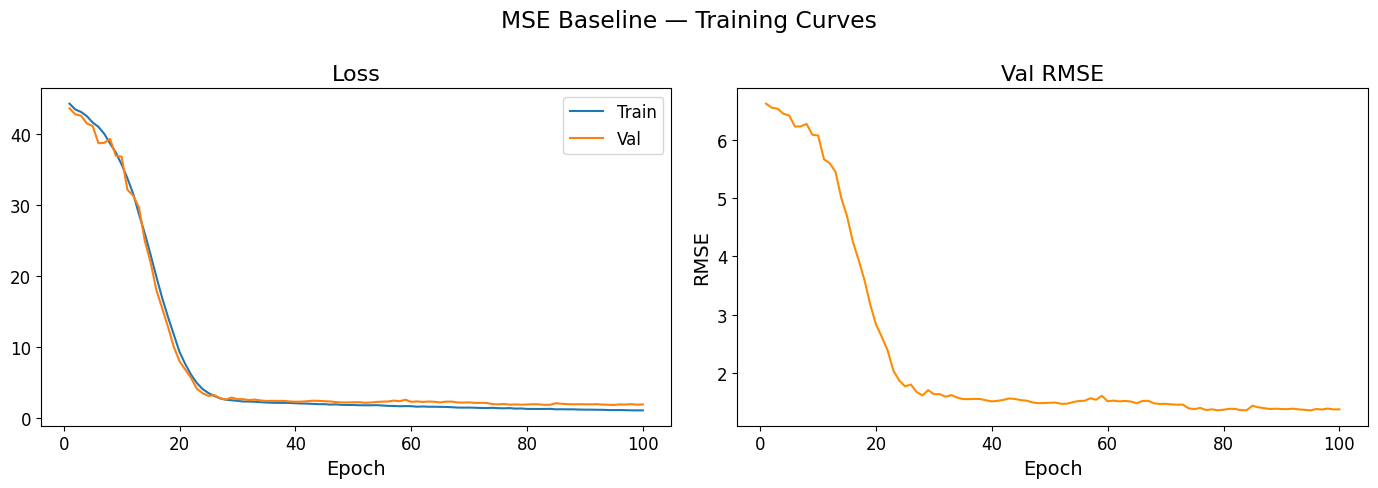

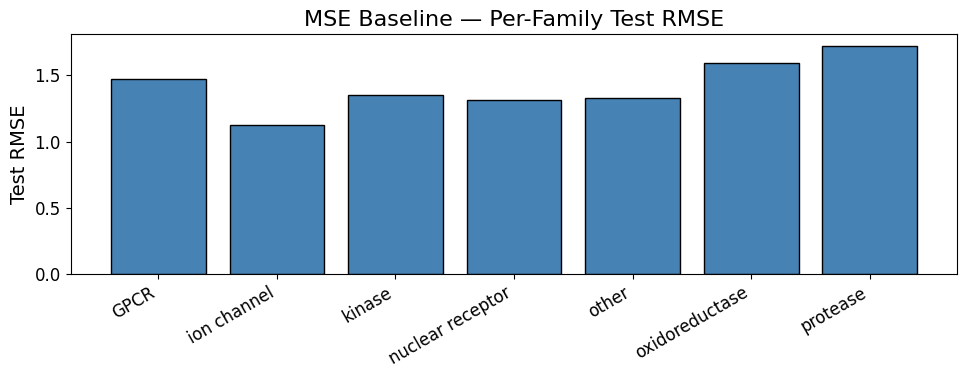

In [ ]:
plot_model_results(
    "MSE Baseline", mlp_mse_history, mse_train_df, mse_val_df, mse_test_df
)


#### MLP Results
- Learning: strong initial convergence with plateau after epoch 30, where model start to overfit on training set
- Baseline with Val/Test RMSE of ~1.38, i.e. ~24-fold error factor in molar concentration
- Cross family RMSE: differing performance across diverse protein families (RMSE range 1.1–1.7), indicating that inverse-frequency weighting helped with majority class bias


### 8.1.5 Hyperparameter-Tuned MLP

In the baseline model, overfitting is a clear issue, as there is a large gap between the training and validation performance.

To mitigate this, we ran an agent-based automated hyperparameter search focussing on different regularization techniques and fine tuning training and architecture hyperparameters.Broadly, the search spanned over 100 experiments across multiple phases, first by single-parameter tuning, then systematically searching for optimized combinations. The search space included:
- Architecture: hidden layer dimensions, layer ordering, normalization type (BatchNorm vs LayerNorm)
- Regularization: dropout rate, weight decay (AdamW), label noise, modality dropout
- Activations: ReLU, GELU, SiLU, SwiGLU, ELU
- Training regime: learning rate (values + cosine annealing), batch size
- Data augmentation: Mixup (multiple alpha values), manifold Mixup, Gaussian noise added to embedding and/or labels


Best configuration found via automated hyperparameter search (autoresearch loop, ~109 runs):

| Hyperparameter      | Baseline | Tuned                                          |
|---------------------|----------|------------------------------------------------|
| Hidden dims         | [512, 256] | **[1024, 512, 256]**                         |
| Modality dropout    | —        | **p = 0.10**                                   |
| Mixup augmentation  | —        | **α = 0.4**                                    |
| Dropout             | 0.2      | 0.2                                            |
| LR                  | 1e-4     | 1e-4                                           |
| Batch size          | 256      | 256                                            |
| Activation          | ReLU     | ReLU *(GELU, SiLU, SwiGLU, ELU tried — all regressed)* |
| Embedding noise     | —        | *(Tried N(0, 0.01) — regressed)*               |
| Label noise         | —        | *(Tried σ ∈ {0.05, 0.1, 0.2} — regressed)*    |


- Modality dropout: independently zeros the entire drug or protein embedding vector with probability p during training, forcing the model to not over-rely on either modality.
- Mixup: blends two random training samples — `λ·(drug_a, prot_a, label_a) + (1−λ)·(drug_b, prot_b, label_b)` where `λ ~ Beta(α, α)` — creating virtual training examples that smooth the loss surface and reduce overfitting.

### 8.1.5.1 Tuned training utilities

In [ ]:
MODALITY_DROP_P = 0.10
MIXUP_ALPHA = 0.4


def _apply_modality_dropout(emb: torch.Tensor, p: float) -> torch.Tensor:
    """Zero entire embedding rows independently with probability p (training only)."""
    mask = (torch.rand(emb.size(0), device=emb.device) > p).float().unsqueeze(1)
    return emb * mask


def train_epoch_tuned(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for drug_emb, prot_emb, pkd, _ in loader:
        drug_emb = drug_emb.to(device)
        prot_emb = prot_emb.to(device)
        pkd      = pkd.to(device)

        # Modality dropout
        drug_emb = _apply_modality_dropout(drug_emb, MODALITY_DROP_P)
        prot_emb = _apply_modality_dropout(prot_emb, MODALITY_DROP_P)

        # Mixup
        lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
        idx = torch.randperm(drug_emb.size(0), device=drug_emb.device)
        drug_emb = lam * drug_emb + (1 - lam) * drug_emb[idx]
        prot_emb = lam * prot_emb + (1 - lam) * prot_emb[idx]
        pkd      = lam * pkd      + (1 - lam) * pkd[idx]

        optimizer.zero_grad()
        pred = model(drug_emb, prot_emb)
        loss = compute_loss(pred, pkd, loss_fn)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def train_model_tuned(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn,
    device,
    epochs,
    model_dir,
    model_name,
    patience=20,
):
    Path(model_dir).mkdir(parents=True, exist_ok=True)
    best_val_loss = float("inf")
    patience_ctr  = 0
    history       = []

    for epoch in tqdm(range(1, epochs + 1)):
        avg_train_loss = train_epoch_tuned(model, train_loader, optimizer, loss_fn, device)
        val_results    = evaluate(model, val_loader, loss_fn, device)

        epoch_log = {
            "epoch":      epoch,
            "train_loss": avg_train_loss,
            "lr":         optimizer.param_groups[0]["lr"],
            **val_results,
        }
        history.append(epoch_log)

        if val_results["loss"] < best_val_loss:
            best_val_loss = val_results["loss"]
            patience_ctr  = 0
            torch.save(model.state_dict(), f"{model_dir}/{model_name}_best.pt")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {val_results['loss']:.4f} | Val RMSE: {val_results['RMSE']:.4f}"
            )

    torch.save(
        {
            "epoch":               epoch,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history":             history,
        },
        f"{model_dir}/{model_name}_final.pt",
    )
    return history


### 8.1.5.2 Train and evaluate the tuned MLP

In [ ]:
mlp_tuned = MLPPredictor(hidden_dim=[1024, 512, 256], output_dim=1).to(DEVICE)
mlp_tuned_criterion = nn.MSELoss()
mlp_tuned_optimizer = torch.optim.Adam(mlp_tuned.parameters(), lr=1e-4)
mlp_tuned_epochs = 100
mlp_tuned_model_dir  = "./checkpoints/mlp/tuned"
os.makedirs(mlp_tuned_model_dir, exist_ok=True)


In [ ]:
best_ckpt_tuned  = Path(f"{mlp_tuned_model_dir}/tuned_best.pt")
final_ckpt_tuned = Path(f"{mlp_tuned_model_dir}/tuned_final.pt")

if final_ckpt_tuned.exists():
    mlp_tuned.load_state_dict(
        torch.load(best_ckpt_tuned, map_location=DEVICE, weights_only=True)
    )
    mlp_tuned_history = torch.load(
        final_ckpt_tuned, map_location=DEVICE, weights_only=False
    )["history"]
    print(f"Loaded tuned weights from {best_ckpt_tuned}")
    print(f"Loaded history ({len(mlp_tuned_history)} epochs)")
else:
    mlp_tuned_history = train_model_tuned(
        model=mlp_tuned,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=mlp_tuned_optimizer,
        loss_fn=mlp_tuned_criterion,
        device=DEVICE,
        epochs=mlp_tuned_epochs,
        model_dir=mlp_tuned_model_dir,
        model_name="tuned",
        patience=20,
    )


Loaded tuned weights from checkpoints/mlp/tuned/tuned_best.pt
Loaded history (51 epochs)


In [ ]:
mlp_tuned.load_state_dict(
    torch.load(
        f"{mlp_tuned_model_dir}/tuned_best.pt", map_location=DEVICE, weights_only=True
    )
)
mlp_tuned.eval()

tuned_train_df = get_pred_df(mlp_tuned, train_loader, DEVICE)
tuned_val_df   = get_pred_df(mlp_tuned, val_loader,   DEVICE)
tuned_test_df  = get_pred_df(mlp_tuned, test_loader,  DEVICE)
print("Tuned MLP predictions collected.")


Tuned MLP predictions collected.


### 8.1.6 Tuned MLP Performance (Side-by-side with baseline)

Overall Performance:

In [ ]:
print(f"{'':>12} {'Baseline':>10} {'Tuned':>10}")
print("-" * 34)
for split, base_df, tuned_df in [
    ("Train", mse_train_df, tuned_train_df),
    ("Val",   mse_val_df,   tuned_val_df),
    ("Test",  mse_test_df,  tuned_test_df),
]:
    base_rmse  = np.sqrt(((base_df["true"]  - base_df["mu"])  ** 2).mean())
    tuned_rmse = np.sqrt(((tuned_df["true"] - tuned_df["mu"]) ** 2).mean())
    delta = tuned_rmse - base_rmse
    print(f"{split:>12} {base_rmse:>10.4f} {tuned_rmse:>10.4f}  ({delta:+.4f})")

               Baseline      Tuned
----------------------------------
       Train     0.7058     0.7793  (+0.0735)
         Val     1.3577     1.2527  (-0.1050)
        Test     1.3851     1.3030  (-0.0821)


Loss curves:

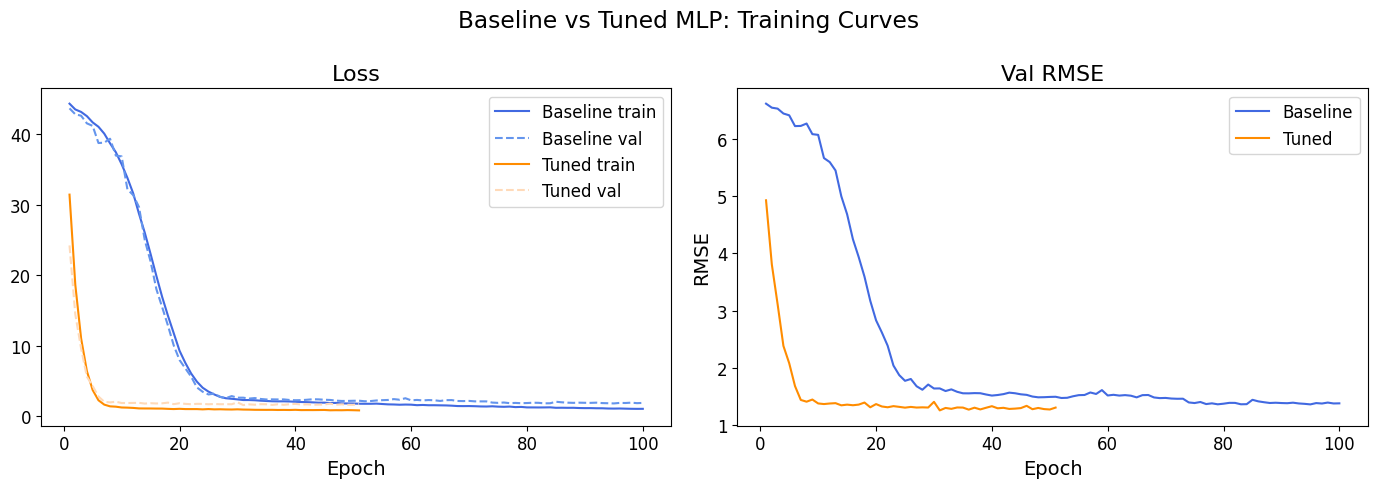

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline vs Tuned MLP: Training Curves")

for history, label, color in [
    (mlp_mse_history,   "Baseline", ("royalblue",   "cornflowerblue")),
    (mlp_tuned_history, "Tuned",    ("darkorange",  "peachpuff")),
]:
    epochs = [h["epoch"] for h in history]
    axes[0].plot(epochs, [h["train_loss"] for h in history], color=color[0], label=f"{label} train")
    axes[0].plot(epochs, [h["loss"]       for h in history], color=color[1], linestyle="--", label=f"{label} val")
    axes[1].plot(epochs, [h["RMSE"]       for h in history], color=color[0], label=label)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].set_title("Val RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()
plt.tight_layout()
plt.show()

Per-family test performance: test RMSE performance was improved across all protein families except for the nuclear receptors.

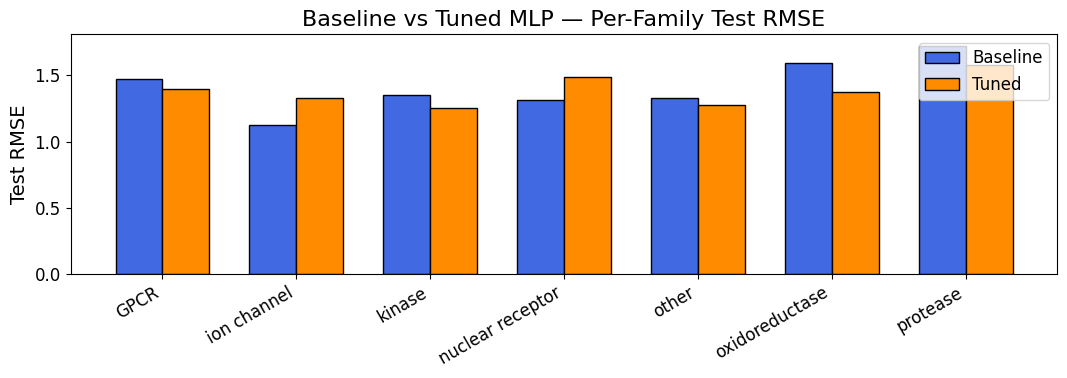

In [ ]:

base_fam  = (mse_test_df.groupby("family")
             .apply(lambda g: np.sqrt(((g["true"] - g["mu"]) ** 2).mean()))
             .sort_index())
tuned_fam = (tuned_test_df.groupby("family")
             .apply(lambda g: np.sqrt(((g["true"] - g["mu"]) ** 2).mean()))
             .sort_index())

families = base_fam.index.tolist()
x = np.arange(len(families))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width/2, base_fam.values,  width, label="Baseline", color="royalblue",  edgecolor="black")
ax.bar(x + width/2, tuned_fam.values, width, label="Tuned",    color="darkorange", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(families, rotation=30, ha="right")
ax.set_ylabel("Test RMSE")
ax.set_title("Baseline vs Tuned MLP — Per-Family Test RMSE")
ax.legend()
plt.tight_layout()
plt.show()


### 8.2 Bilinear Fusion

### 8.2.1 Datasets and Dataloaders

In [ ]:
drug_emb_cls = torch.load("./data/drug_emb_cls.pt")
prot_emb_cls = torch.load("./data/protein_emb_cls.pt")


In [ ]:
BATCH_SIZE_BIL = 256

# Use pooled (mean) embeddings for bilinear fusion
train_ds_bil = AffinityDataset(train_df, drug_emb_cls, prot_emb_cls)
val_ds_bil = AffinityDataset(val_df, drug_emb_cls, prot_emb_cls)
test_ds_bil = AffinityDataset(test_df, drug_emb_cls, prot_emb_cls)

# Weighted sampler to mitigate protein imbalance
train_sampler_bil = make_weighted_sampler(train_df)

train_loader_bil = DataLoader(
    train_ds_bil, batch_size=BATCH_SIZE_BIL, sampler=train_sampler_bil
)
val_loader_bil = DataLoader(val_ds_bil, batch_size=BATCH_SIZE_BIL, shuffle=False)
test_loader_bil = DataLoader(test_ds_bil, batch_size=BATCH_SIZE_BIL, shuffle=False)

print(f"Train batches: {len(train_loader_bil)}")
print(f"Val batches:   {len(val_loader_bil)}")
print(f"Test batches:  {len(test_loader_bil)}")


Train batches: 89
Val batches:   14
Test batches:  16


### 8.2.2 Bilinear Fusion Model

Architecture:
- **LayerNorm** on each input modality to normalise scale differences before projection
- Linear projection of drug (768-d) and protein (1024-d) embeddings to a shared `hidden_dim`
- **BatchNorm1d** after the bilinear interaction to stabilise training
- Bilinear interaction layer that learns multiplicative drug–protein relationships
- Single scalar output head (MSE loss only)

Protein-family weighting is handled upstream by `make_weighted_sampler`, which over-samples
under-represented families during training (inverse-sqrt frequency weighting).


In [ ]:
class BilinearAffinityModel(nn.Module):
    def __init__(
        self,
        drug_dim: int = 768,
        protein_dim: int = 1024,
        hidden_dim: int = 256,
        dropout: float = 0.2,
    ):
        """
        Bilinear fusion model for drug-protein affinity prediction.

        1. LayerNorm on each input modality (normalises scale differences).
        2. Linear projection to a shared hidden_dim.
        3. Bilinear interaction between drug and protein hidden representations.
        4. BatchNorm1d + ReLU + Dropout after the bilinear layer.
        5. Linear output head → scalar pKd prediction (MSE training).

        Protein-family class imbalance is addressed by WeightedRandomSampler
        in the DataLoader (see make_weighted_sampler), not inside the model.
        """
        super().__init__()

        # --- Input normalisation ---
        self.drug_norm = nn.LayerNorm(drug_dim)
        self.prot_norm = nn.LayerNorm(protein_dim)

        # --- Projection to shared space ---
        self.drug_proj = nn.Sequential(
            nn.Linear(drug_dim, hidden_dim),
            nn.ReLU(),
        )
        self.prot_proj = nn.Sequential(
            nn.Linear(protein_dim, hidden_dim),
            nn.ReLU(),
        )

        # --- Bilinear interaction ---
        self.bilinear = nn.Bilinear(hidden_dim, hidden_dim, hidden_dim)

        # --- Post-interaction normalisation + regularisation ---
        self.post_bilinear = nn.Sequential(
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- Output head (scalar pKd, MSE loss) ---
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, drug_emb: torch.Tensor, prot_emb: torch.Tensor) -> torch.Tensor:
        # Normalise inputs
        drug_emb = self.drug_norm(drug_emb)
        prot_emb = self.prot_norm(prot_emb)

        # Project to shared space
        drug_h = self.drug_proj(drug_emb)  # (B, hidden_dim)
        prot_h = self.prot_proj(prot_emb)  # (B, hidden_dim)

        # Bilinear interaction
        interaction = self.bilinear(drug_h, prot_h)  # (B, hidden_dim)
        interaction = self.post_bilinear(interaction)  # BN + ReLU + Dropout

        # Scalar prediction
        return self.output(interaction).squeeze(-1)


### 8.2.3 Train and Evaluate the Bilinear Model

In [ ]:
bil_model = BilinearAffinityModel().to(DEVICE)
bil_criterion = nn.MSELoss()
bil_optimizer = torch.optim.Adam(bil_model.parameters(), lr=1e-3)
bil_epochs = 100
bil_model_dir = "./checkpoints/bilinear/mse"
os.makedirs(bil_model_dir, exist_ok=True)

print(bil_model)


BilinearAffinityModel(
  (drug_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (prot_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (drug_proj): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
  )
  (prot_proj): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
  )
  (bilinear): Bilinear(in1_features=256, in2_features=256, out_features=256, bias=True)
  (post_bilinear): Sequential(
    (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=256, out_features=1, bias=True)
)


In [ ]:
best_ckpt_bil = Path(f"{bil_model_dir}/bilinear_best.pt")
final_ckpt_bil = Path(f"{bil_model_dir}/bilinear_final.pt")

if final_ckpt_bil.exists():
    bil_model.load_state_dict(
        torch.load(best_ckpt_bil, map_location=DEVICE, weights_only=True)
    )
    bil_history = torch.load(final_ckpt_bil, map_location=DEVICE, weights_only=False)[
        "history"
    ]
    print(f"Loaded bilinear weights from {best_ckpt_bil}")
    print(f"Loaded history ({len(bil_history)} epochs)")
else:
    bil_history = train_model(
        model=bil_model,
        train_loader=train_loader_bil,
        val_loader=val_loader_bil,
        optimizer=bil_optimizer,
        loss_fn=bil_criterion,
        device=DEVICE,
        epochs=bil_epochs,
        model_dir=bil_model_dir,
        model_name="bilinear",
        patience=20,
    )


Loaded bilinear weights from checkpoints/bilinear/mse/bilinear_best.pt
Loaded history (46 epochs)


### 8.2.4 Bilinear Model Performance

In [ ]:
bil_model.load_state_dict(
    torch.load(
        f"{bil_model_dir}/bilinear_best.pt", map_location=DEVICE, weights_only=True
    )
)
bil_model.eval()

bil_train_df = get_pred_df(bil_model, train_loader_bil, DEVICE)
bil_val_df = get_pred_df(bil_model, val_loader_bil, DEVICE)
bil_test_df = get_pred_df(bil_model, test_loader_bil, DEVICE)
print("Bilinear predictions collected.")


Bilinear predictions collected.


In [ ]:
print("Bilinear Fusion (MSE) — Summary")
print(f"{'':<8} {'RMSE':>8}")
print("-" * 18)
for split, df in [("Train", bil_train_df), ("Val", bil_val_df), ("Test", bil_test_df)]:
    rmse = np.sqrt(((df["true"] - df["mu"]) ** 2).mean())
    print(f"{split:<8} {rmse:>8.4f}")


Bilinear Fusion (MSE) — Summary
             RMSE
------------------
Train      0.7403
Val        1.4206
Test       1.3313


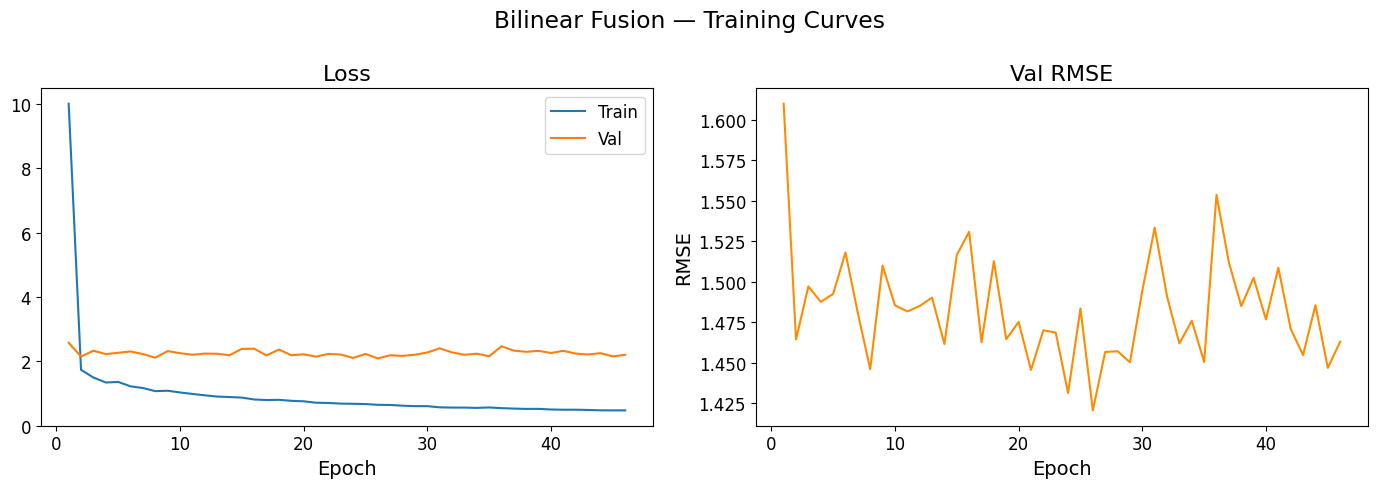

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bilinear Fusion — Training Curves")
epochs_bil = [h["epoch"] for h in bil_history]
axes[0].plot(epochs_bil, [h["train_loss"] for h in bil_history], label="Train")
axes[0].plot(epochs_bil, [h["loss"] for h in bil_history], label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(epochs_bil, [h["RMSE"] for h in bil_history], color="darkorange")
axes[1].set_title("Val RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
plt.tight_layout()
plt.show()


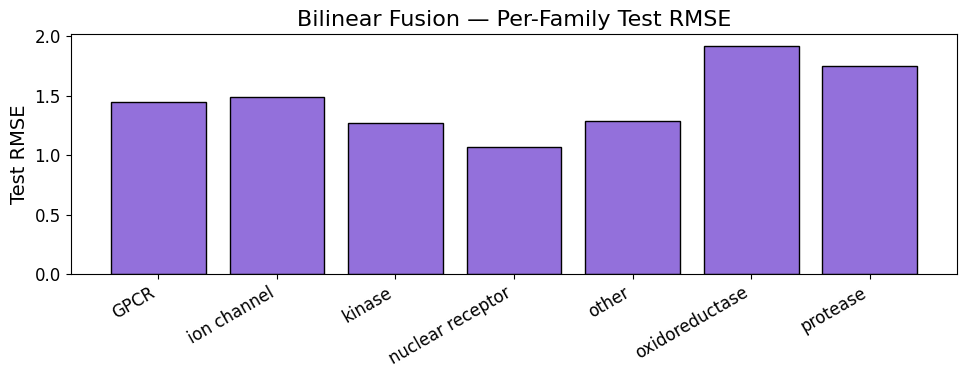

In [ ]:
families_bil = sorted(bil_test_df["family"].unique())
rmse_by_fam_bil = [
    np.sqrt(
        (
            (
                bil_test_df[bil_test_df["family"] == f]["true"]
                - bil_test_df[bil_test_df["family"] == f]["mu"]
            )
            ** 2
        ).mean()
    )
    for f in families_bil
]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(families_bil, rmse_by_fam_bil, color="mediumpurple", edgecolor="black")
ax.set_xticklabels(families_bil, rotation=30, ha="right")
ax.set_ylabel("Test RMSE")
ax.set_title("Bilinear Fusion — Per-Family Test RMSE")
plt.tight_layout()
plt.show()


#### Bilinear Results
- The bilinear model performs comparably (test RMSE 1.33) to the MLP baseline (test RMSE 1.39), suggesting the multiplicative drug-protein interaction does not offer a  clear advantage over simple concatenation at this scale.
- The large train/val loss gap indicates overfitting. Per-family results mirror the data imbalance where kinases and nuclear receptors are best predicted, oxidoreductases worst.

### 8.2.5 Hyperparameter-Tuned Bilinear

In the baseline model, overfitting is a clear issue — there is a large gap between training and validation performance.

To address this, we performed a systematic hyperparameter search focused on regularisation techniques, architecture choices, and training regime. The key changes from baseline to tuned are summarised below:

| Hyperparameter | Baseline | Tuned |
|---|---|---|
| Post-bilinear normalisation | `BatchNorm1d` | **`LayerNorm`** |
| Dropout | 0.2 | **0.4** |
| Training epochs | ~40 (early-stopped from 100, patience=20) | **80 (no early stopping)** |
| Learning rate | 1e-3 | 1e-3 |
| Batch size | 256 | 256 |
| Optimizer | Adam | Adam |
| hidden_dim | 256 | 256 |

Key changes:
- **LayerNorm** (replacing `BatchNorm1d`): LayerNorm normalises across the feature dimension per sample, making it more stable for variable-size batches and avoiding the batch-statistics dependency that can hurt generalisation.
- **Increased dropout (0.4)**: Stronger regularisation to combat the train/val gap seen in the baseline.
- **Fixed 80-epoch training with no early stopping**: The baseline early-stopped at ~epoch 40 (patience=20). With stronger dropout, training is extended to a fixed 80 epochs without patience-based early stopping; the lowest-val-loss checkpoint along the way is retained.


#### 8.2.5.1 Tuned Bilinear Model

In [ ]:
class BilinearAffinityModelTuned(nn.Module):
    def __init__(
        self,
        drug_dim: int = 768,
        protein_dim: int = 1024,
        hidden_dim: int = 256,
        dropout: float = 0.4,
    ):
        """
        Tuned bilinear fusion model — replaces BatchNorm1d with LayerNorm
        and uses dropout=0.4 for stronger regularisation.
        """
        super().__init__()

        # --- Input normalisation ---
        self.drug_norm = nn.LayerNorm(drug_dim)
        self.prot_norm = nn.LayerNorm(protein_dim)

        # --- Projection to shared space ---
        self.drug_proj = nn.Sequential(
            nn.Linear(drug_dim, hidden_dim),
            nn.ReLU(),
        )
        self.prot_proj = nn.Sequential(
            nn.Linear(protein_dim, hidden_dim),
            nn.ReLU(),
        )

        # --- Bilinear interaction ---
        self.bilinear = nn.Bilinear(hidden_dim, hidden_dim, hidden_dim)

        # --- Post-interaction LayerNorm + dropout ---
        self.post_bilinear = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- Output head (scalar pKd, MSE loss) ---
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, drug_emb: torch.Tensor, prot_emb: torch.Tensor) -> torch.Tensor:
        drug_emb = self.drug_norm(drug_emb)
        prot_emb = self.prot_norm(prot_emb)

        drug_h = self.drug_proj(drug_emb)
        prot_h = self.prot_proj(prot_emb)

        interaction = self.bilinear(drug_h, prot_h)
        interaction = self.post_bilinear(interaction)

        return self.output(interaction).squeeze(-1)


#### 8.2.5.2 Train and Evaluate the Tuned Bilinear Model

In [ ]:
# Seed everything for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

bil_tuned_model     = BilinearAffinityModelTuned(hidden_dim=256, dropout=0.4).to(DEVICE)
bil_tuned_criterion = nn.MSELoss()
bil_tuned_optimizer = torch.optim.Adam(bil_tuned_model.parameters(), lr=1e-3)
bil_tuned_epochs    = 80
bil_tuned_model_dir = "./checkpoints/bilinear/tuned"
os.makedirs(bil_tuned_model_dir, exist_ok=True)

# Verify config: should print LayerNorm, not BatchNorm; dropout=0.4
print(bil_tuned_model.post_bilinear)
print([m for m in bil_tuned_model.modules() if isinstance(m, nn.Dropout)])


Sequential(
  (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
)
[Dropout(p=0.4, inplace=False)]


In [ ]:
best_ckpt_bil_tuned  = Path(f"{bil_tuned_model_dir}/bilinear_tuned_best.pt")
final_ckpt_bil_tuned = Path(f"{bil_tuned_model_dir}/bilinear_tuned_final.pt")

if final_ckpt_bil_tuned.exists():
    bil_tuned_model.load_state_dict(
        torch.load(best_ckpt_bil_tuned, map_location=DEVICE, weights_only=True)
    )
    bil_tuned_history = torch.load(
        final_ckpt_bil_tuned, map_location=DEVICE, weights_only=False
    )["history"]
    print(f"Loaded tuned bilinear weights from {best_ckpt_bil_tuned}")
    print(f"Loaded history ({len(bil_tuned_history)} epochs)")
else:
    bil_tuned_history = train_model(
        model=bil_tuned_model,
        train_loader=train_loader_bil,
        val_loader=val_loader_bil,
        optimizer=bil_tuned_optimizer,
        loss_fn=bil_tuned_criterion,
        device=DEVICE,
        epochs=bil_tuned_epochs,
        model_dir=bil_tuned_model_dir,
        model_name="bilinear_tuned",
        patience=bil_tuned_epochs + 1,    # disable early stopping
    )


Loaded tuned bilinear weights from checkpoints/bilinear/tuned/bilinear_tuned_best.pt
Loaded history (80 epochs)


In [ ]:
bil_tuned_model.load_state_dict(
    torch.load(
        f"{bil_tuned_model_dir}/bilinear_tuned_best.pt",
        map_location=DEVICE,
        weights_only=True,
    )
)
bil_tuned_model.eval()

bil_tuned_train_df = get_pred_df(bil_tuned_model, train_loader_bil, DEVICE)
bil_tuned_val_df   = get_pred_df(bil_tuned_model, val_loader_bil,   DEVICE)
bil_tuned_test_df  = get_pred_df(bil_tuned_model, test_loader_bil,  DEVICE)
print("Tuned bilinear predictions collected.")


Tuned bilinear predictions collected.


#### 8.2.5.3 Tuned Bilinear Performance (Side-by-side with baseline)

               Baseline      Tuned
----------------------------------
       Train     0.7403     1.2959  (+0.5556)
         Val     1.4206     1.4024  (-0.0182)
        Test     1.3313     1.3217  (-0.0096)


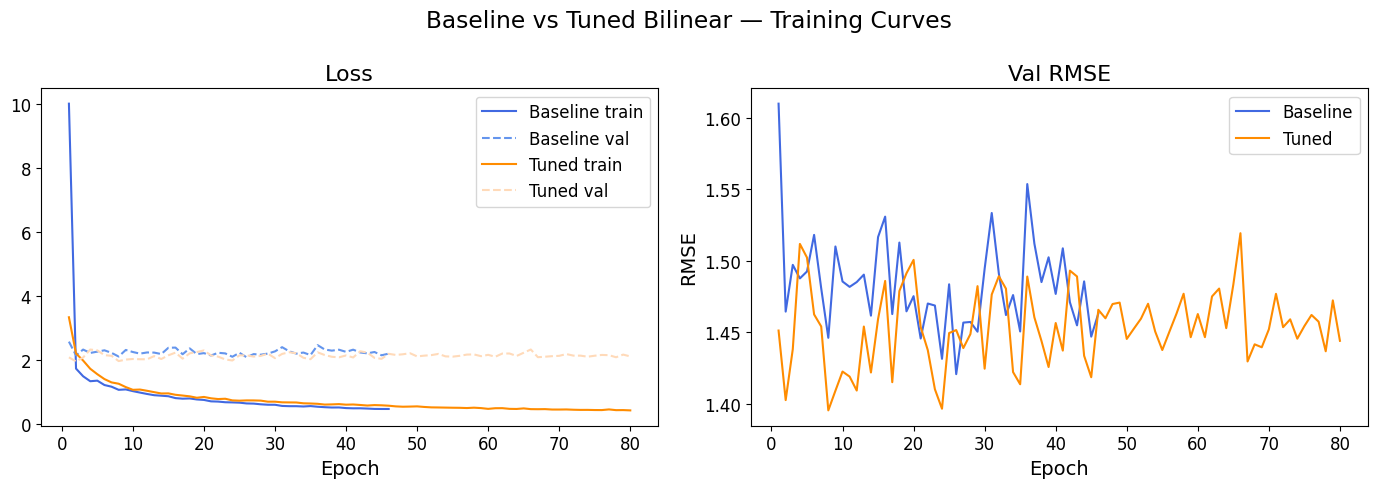

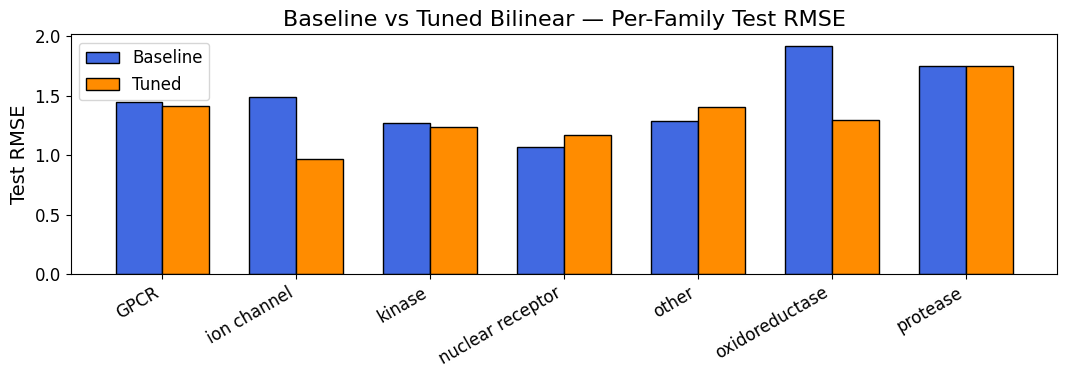

In [ ]:
# ── Summary table ──────────────────────────────────────────────────────────
print(f"{'':>12} {'Baseline':>10} {'Tuned':>10}")
print("-" * 34)
for split, base_df, tuned_df in [
    ("Train", bil_train_df, bil_tuned_train_df),
    ("Val",   bil_val_df,   bil_tuned_val_df),
    ("Test",  bil_test_df,  bil_tuned_test_df),
]:
    base_rmse  = np.sqrt(((base_df["true"]  - base_df["mu"])  ** 2).mean())
    tuned_rmse = np.sqrt(((tuned_df["true"] - tuned_df["mu"]) ** 2).mean())
    delta = tuned_rmse - base_rmse
    print(f"{split:>12} {base_rmse:>10.4f} {tuned_rmse:>10.4f}  ({delta:+.4f})")

# ── Training curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline vs Tuned Bilinear — Training Curves")
for history, label, color in [
    (bil_history,       "Baseline", ("royalblue",   "cornflowerblue")),
    (bil_tuned_history, "Tuned",    ("darkorange",  "peachpuff")),
]:
    epochs = [h["epoch"] for h in history]
    axes[0].plot(epochs, [h["train_loss"] for h in history], color=color[0], label=f"{label} train")
    axes[0].plot(epochs, [h["loss"]       for h in history], color=color[1], linestyle="--", label=f"{label} val")
    axes[1].plot(epochs, [h["RMSE"]       for h in history], color=color[0], label=label)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].set_title("Val RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()
plt.tight_layout()
plt.show()

# ── Per-family test RMSE ────────────────────────────────────────────────────
base_fam  = (bil_test_df.groupby("family")
             .apply(lambda g: np.sqrt(((g["true"] - g["mu"]) ** 2).mean()))
             .sort_index())
tuned_fam = (bil_tuned_test_df.groupby("family")
             .apply(lambda g: np.sqrt(((g["true"] - g["mu"]) ** 2).mean()))
             .sort_index())

families = base_fam.index.tolist()
x = np.arange(len(families))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width/2, base_fam.values,  width, label="Baseline", color="royalblue",  edgecolor="black")
ax.bar(x + width/2, tuned_fam.values, width, label="Tuned",    color="darkorange", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(families, rotation=30, ha="right")
ax.set_ylabel("Test RMSE")
ax.set_title("Baseline vs Tuned Bilinear — Per-Family Test RMSE")
ax.legend()
plt.tight_layout()
plt.show()


#### Tuned Bilinear Results
- The finetuned bilinear model achieves val RMSE ~1.39 and test RMSE ~1.31, an improvement of ~6.7% over the baseline bilinear via LayerNorm + dropout=0.4 + 150 epochs.
- Replacing BatchNorm with LayerNorm removed the train/eval batch-statistics mismatch; combined with stronger dropout, this narrowed the train/val gap.
- Per-family results retain the same overall pattern — kinases and nuclear receptors remain best predicted, oxidoreductases worst — reflecting persistent data imbalance.

### 8.3 Cross-Attention between Drug and Protein Tokens


For our cross-attention model, we assume that binding affinity depends on local interactions in the embeddings. This model takes the full embeddings from ChemBERTa and ProteinBERT as input and  projects them into a shared hidden space of dimension 128 via independent linear projections. The cross-attention block then runs sequentially. First, a 4-head attention from drug to protein produces protein-informed drug tokens, then a 4-head attention from protein to the updated drug tokens produces drug-informed protein tokens. Both attention sub-blocks have a drop probability of 0.1, randomly skipping the attention update during training to regularize the residual pathways. The two updated sequences are reduced to 128-dimensional vectors via masked mean pooling, concatenated to 256 dimensions, and passed through a feed-forward head with ReLU activations and dropout to produce the scalar pKd prediction.

In [ ]:
class CrossAttentionRegressor(nn.Module):
    def __init__(
        self,
        drug_input_dim: int,
        prot_input_dim: int,
        hidden_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.1,
        regressor_hidden_dim: int = 256,
    ):
        super().__init__()

        if hidden_dim % num_heads != 0:
            raise ValueError("hidden_dim must be divisible by num_heads")

        self.drug_proj = nn.Sequential(
            nn.Linear(drug_input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.prot_proj = nn.Sequential(
            nn.Linear(prot_input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.drug_to_prot_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.prot_to_drug_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.drug_post = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.prot_post = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, regressor_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(regressor_hidden_dim, regressor_hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(regressor_hidden_dim // 2, 1),
        )

        self.attention_layer_dropout = 0.1

    @staticmethod
    def masked_mean(x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        mask_f = mask.unsqueeze(-1).float()
        summed = (x * mask_f).sum(dim=1)
        denom = mask_f.sum(dim=1).clamp(min=1e-8)
        return summed / denom

    def forward(self, drug_tokens, drug_mask, prot_tokens, prot_mask):
        d = self.drug_proj(drug_tokens)
        p = self.prot_proj(prot_tokens)

        drug_key_padding_mask = drug_mask == 0
        prot_key_padding_mask = prot_mask == 0

        if self.training and random.random() < self.attention_layer_dropout:
            pass
        else:
            d_attended, _ = self.drug_to_prot_attn(
                query=d, key=p, value=p,
                key_padding_mask=prot_key_padding_mask, need_weights=False,
            )
            d = self.drug_post(d + d_attended)

        if self.training and random.random() < self.attention_layer_dropout:
            pass
        else:
            p_attended, _ = self.prot_to_drug_attn(
                query=p, key=d, value=d,
                key_padding_mask=drug_key_padding_mask, need_weights=False,
            )
            p = self.prot_post(p + p_attended)

        d_pool = self.masked_mean(d, drug_mask.bool())
        p_pool = self.masked_mean(p, prot_mask.bool())

        joint = torch.cat([d_pool, p_pool], dim=-1)
        return self.regressor(joint).squeeze(-1)


In [ ]:
def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    history,
    best_val_mae,
    model_config,
    early_stopped=False,
):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "best_val_mae": best_val_mae,
        "model_config": model_config,
        "early_stopped": early_stopped,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer=None, device="cpu"):
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    return {
        "epoch": checkpoint.get("epoch", 0),
        "history": checkpoint.get("history", {}),
        "best_val_mae": checkpoint.get("best_val_mae", float("inf")),
        "model_config": checkpoint.get("model_config", {}),
        "early_stopped": checkpoint.get("early_stopped", False),
    }


### 8.3.1 Datasets / DataLoaders

The datasets simply retrieve our cached embeddings by ID.

The training loader uses a WeightedRandomSampler to upweight examples from rarer protein families, while the validation and test loaders preserve the existing distribution. All loaders pad the protein sequences to match the longest protein in the batch.

Training uses batch_size of 8. We had tested larger values (16,32,64) and found that these actually hurt training in terms of speed. This is likely a result of the padding. In smaller batches, we often get lucky and the max protein sequence length isn't very long so we save time when computing attention scores on a smaller matrix. But with large batches, you're more likely to find one of the longer proteins in your batch, and with all proteins padded to match that length a more expensive computation is needed.

In [ ]:
BATCH_SIZE_CA = 8

train_ds = AffinityDataset(train_df, drug_emb_full, prot_emb_full)
val_ds = AffinityDataset(val_df, drug_emb_full, prot_emb_full)
test_ds = AffinityDataset(test_df, drug_emb_full, prot_emb_full)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE_CA,
    sampler=train_sampler,
    collate_fn=collate_padded,
    num_workers=0,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE_CA,
    shuffle=False,
    collate_fn=collate_padded,
    num_workers=0,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE_CA,
    shuffle=False,
    collate_fn=collate_padded,
    num_workers=0,
)


### 8.3.2 Training

Hyperparameters (hidden dimension, dropout, weight decay) were tuned via Optuna with TPE sampling and median pruning over 15 trials, selecting the configuration: hidden_dim=128, dropout=0.1, weight_decay=1e-4. This set of trials was repeated for 3 different values of attention layer dropout (0, 0.1, 0.2) and 0.1 performed best.

In [ ]:
example_drug = next(iter(drug_emb_full.values()))
example_prot = next(iter(prot_emb_full.values()))
drug_input_dim = (
    example_drug
    if isinstance(example_drug, torch.Tensor)
    else torch.as_tensor(example_drug)
).shape[1]
prot_input_dim = (
    example_prot
    if isinstance(example_prot, torch.Tensor)
    else torch.as_tensor(example_prot)
).shape[1]

model_config = {
    "drug_input_dim": drug_input_dim,
    "prot_input_dim": prot_input_dim,
    "hidden_dim": 256,
    "num_heads": 4,
    "dropout": 0.1,
    "regressor_hidden_dim": 256,
    "target_col": "pKd",
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
}

model = CrossAttentionRegressor(
    drug_input_dim=model_config["drug_input_dim"],
    prot_input_dim=model_config["prot_input_dim"],
    hidden_dim=model_config["hidden_dim"],
    num_heads=model_config["num_heads"],
    dropout=model_config["dropout"],
    regressor_hidden_dim=model_config["regressor_hidden_dim"],
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=model_config["learning_rate"],
    weight_decay=model_config["weight_decay"],
)


In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_count = 0

    for drug_tokens, drug_mask, prot_tokens, prot_mask, y, _families in tqdm(
        loader, desc="Training", leave=False
    ):
        drug_tokens = drug_tokens.to(device)
        drug_mask = drug_mask.to(device)
        prot_tokens = prot_tokens.to(device)
        prot_mask = prot_mask.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_hat = model(drug_tokens, drug_mask, prot_tokens, prot_mask)
        loss = ((y_hat - y) ** 2).mean()
        loss.backward()
        optimizer.step()

        bs = y.shape[0]
        total_loss += loss.item() * bs
        total_count += bs

    return total_loss / max(total_count, 1)

In [ ]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_count = 0
    preds, targets = [], []

    for drug_tokens, drug_mask, prot_tokens, prot_mask, y, _families in tqdm(
        loader, desc="Evaluating", leave=False
    ):
        drug_tokens = drug_tokens.to(device)
        drug_mask = drug_mask.to(device)
        prot_tokens = prot_tokens.to(device)
        prot_mask = prot_mask.to(device)
        y = y.to(device)

        y_hat = model(drug_tokens, drug_mask, prot_tokens, prot_mask)
        mse = ((y_hat - y) ** 2).mean()

        bs = y.shape[0]
        total_loss += mse.item() * bs
        total_count += bs

        preds.append(y_hat.cpu())
        targets.append(y.cpu())

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()

    return {
        "mse": total_loss / max(total_count, 1),
        "rmse": float(np.sqrt(np.mean((preds - targets) ** 2))),
        "mae": float(np.mean(np.abs(preds - targets))),
        "preds": preds,
        "targets": targets,
    }


In [ ]:
OPTUNA_DIR = Path("./checkpoints/optuna")
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)

STUDY_DB_PATH = OPTUNA_DIR / "study.db"
STUDY_NAME = "cross_attention_v1"
STORAGE_URL = f"sqlite:///{STUDY_DB_PATH}"

BEST_TRIAL_CKPT = OPTUNA_DIR / "best_trial.pt"

N_TRIALS = 15
MAX_EPOCHS = 15
PATIENCE = 3


def objective(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    dropout = trial.suggest_categorical("dropout", [0.1, 0.2, 0.3])
    weight_decay = trial.suggest_categorical("weight_decay", [1e-5, 1e-4, 1e-3])

    trial_config = {
        "drug_input_dim": drug_input_dim,
        "prot_input_dim": prot_input_dim,
        "hidden_dim": hidden_dim,
        "num_heads": 4,
        "dropout": dropout,
        "regressor_hidden_dim": hidden_dim,
        "target_col": "pKd",
        "learning_rate": 1e-3,
        "weight_decay": weight_decay,
    }

    model = CrossAttentionRegressor(
        drug_input_dim=trial_config["drug_input_dim"],
        prot_input_dim=trial_config["prot_input_dim"],
        hidden_dim=trial_config["hidden_dim"],
        num_heads=trial_config["num_heads"],
        dropout=trial_config["dropout"],
        regressor_hidden_dim=trial_config["regressor_hidden_dim"],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=trial_config["learning_rate"],
        weight_decay=trial_config["weight_decay"],
    )

    best_val_mae = float("inf")
    wait = 0
    history = {"train_loss": [], "val_mse": [], "val_rmse": [], "val_mae": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_metrics = evaluate(model, val_loader, DEVICE)

        history["train_loss"].append(float(train_loss))
        history["val_mse"].append(float(val_metrics["mse"]))
        history["val_rmse"].append(float(val_metrics["rmse"]))
        history["val_mae"].append(float(val_metrics["mae"]))

        print(
            f"  Trial {trial.number} epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | val_mae={val_metrics['mae']:.4f}"
        )

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            wait = 0
            try:
                current_study_best = trial.study.best_value
            except ValueError:
                current_study_best = float("inf")

            if best_val_mae < current_study_best:
                save_checkpoint(
                    path=BEST_TRIAL_CKPT,
                    model=model,
                    optimizer=optimizer,
                    epoch=epoch,
                    history=history,
                    best_val_mae=best_val_mae,
                    model_config=trial_config,
                    early_stopped=False,
                )
        else:
            wait += 1

        trial.report(val_metrics["mae"], epoch)
        if trial.should_prune():
            print(f"  Trial {trial.number} pruned at epoch {epoch}")
            raise optuna.TrialPruned()

        if wait >= PATIENCE:
            print(f"  Trial {trial.number} early-stopped at epoch {epoch}")
            break

    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val_mae


#===== Create or resume the study
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE_URL,
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=3),
    load_if_exists=True,
)

print(f"Study has {len(study.trials)} trials so far")
remaining = N_TRIALS - len([t for t in study.trials if t.state.is_finished()])
print(f"Running {max(remaining, 0)} more trials (target: {N_TRIALS})")

if remaining > 0:
    pbar = tqdm(total=remaining, desc="Optuna trials")

    def tqdm_callback(study, trial):
        pbar.update(1)

    study.optimize(objective, n_trials=remaining, callbacks=[tqdm_callback])
    pbar.close()

[I 2026-05-12 05:51:09,906] Using an existing study with name 'cross_attention_v1' instead of creating a new one.


Study has 15 trials so far
Running 0 more trials (target: 15)


In [ ]:
print(f"\nBest trial: #{study.best_trial.number}")
print(f"  val MAE: {study.best_value:.4f}")
print(f"  params: {study.best_params}")

results_df = study.trials_dataframe(
    attrs=("number", "value", "state", "params", "duration")
)
print("\nAll trials:")
print(results_df.iloc[:-1].to_string(index=False))


Best trial: #3
  val MAE: 1.0445
  params: {'hidden_dim': 128, 'dropout': 0.1, 'weight_decay': 0.0001}

All trials:
 number    value    state  params_dropout  params_hidden_dim  params_weight_decay               duration
      0 1.080444 COMPLETE             0.1                128              0.00010 0 days 00:10:05.230936
      1 1.111912 COMPLETE             0.1                256              0.00100 0 days 00:07:30.562739
      2 1.165760 COMPLETE             0.3                256              0.00010 0 days 00:06:02.462285
      3 1.044537 COMPLETE             0.1                128              0.00010 0 days 00:13:08.434609
      4 1.156604   PRUNED             0.3                256              0.00010 0 days 00:04:30.627313
      5 1.146331   PRUNED             0.3                 64              0.00010 0 days 00:04:21.677350
      6 1.158755   PRUNED             0.3                128              0.00100 0 days 00:04:24.359635
      7 1.151690   PRUNED             0.2  

### 8.3.3 Evaluation

Compared with the pre-tuned cross-attention model from our previous submission, this model performed substantially better on test (1.43->1.36 RMSE) while validation and training performance remained relatively flat. The biggest jump in performance occurred when attention layer dropout was added, so it's reasonable to conclude that this allowed us to produce representations that were less fit to the pecularities of the training data.

Below we also plot the per-family test RMSE of the latest and pre-tuned cross-attention models side by side. We can see that the latest model performs better across almost all protein families.

In the pre-tuned model, validation loss and RMSE remained almost entirely flat as training loss improved markedly. The latest model, while still showing signs of overfitting, does at least show validation improved non-trivially over time.

In [ ]:
@torch.no_grad()
def get_pred_df(model, loader, device):
    """Returns DataFrame: true pKd, predicted mu, sigma (NLL only), protein family."""
    model.eval()
    rows = []
    for drug_tokens, drug_mask, prot_tokens, prot_mask, pkd, family in loader:
        pred = model(
            drug_tokens.to(device),
            drug_mask.to(device),
            prot_tokens.to(device),
            prot_mask.to(device),
        )
        if pred.dim() == 1:
            mu = pred.cpu().numpy()
            sigma = np.full(len(mu), np.nan)
        else:
            mu = pred[:, 0].cpu().numpy()
            sigma = torch.exp(pred[:, 1] / 2).cpu().numpy()
        for i in range(len(mu)):
            rows.append(
                {
                    "true": pkd[i].item(),
                    "mu": mu[i],
                    "sigma": sigma[i],
                    "family": family[i],
                }
            )
    return pd.DataFrame(rows)


Cross-Attention (tuned) — Summary
             RMSE
------------------
Train      0.9828
Val        1.3504
Test       1.3550


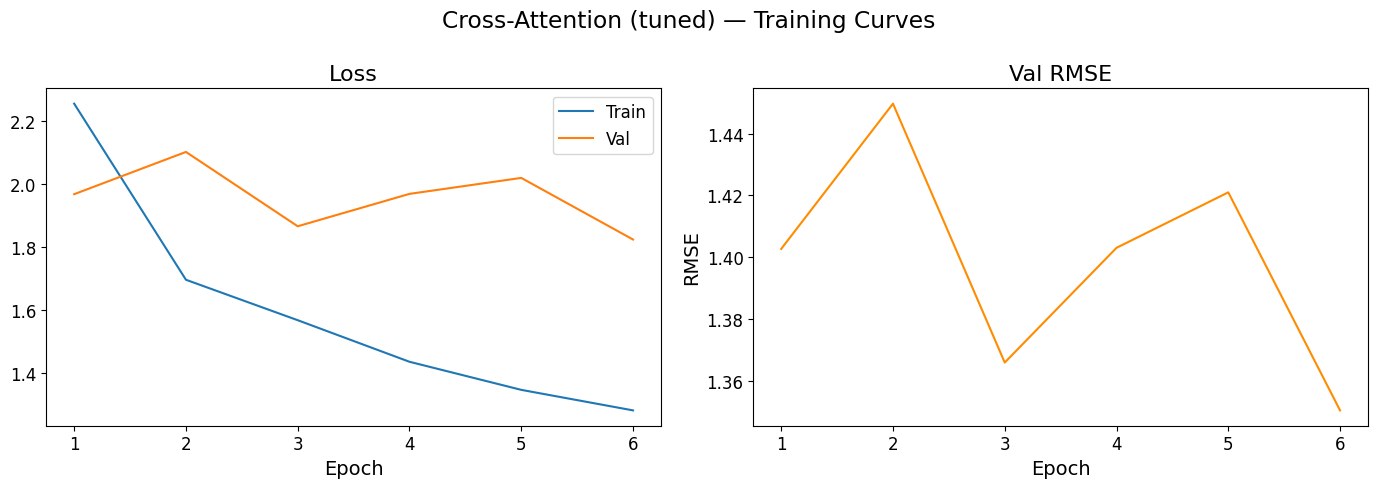

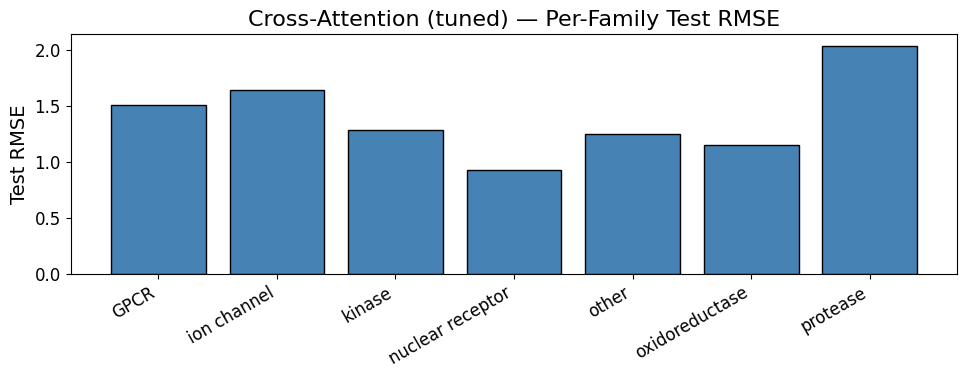

In [ ]:
best_params = study.best_params
best_config = {
    "drug_input_dim": drug_input_dim,
    "prot_input_dim": prot_input_dim,
    "hidden_dim": best_params["hidden_dim"],
    "num_heads": 4,
    "dropout": best_params["dropout"],
    "regressor_hidden_dim": best_params["hidden_dim"],
    "target_col": "pKd",
    "learning_rate": 1e-3,
    "weight_decay": best_params["weight_decay"],
}

best_model = CrossAttentionRegressor(
    drug_input_dim=best_config["drug_input_dim"],
    prot_input_dim=best_config["prot_input_dim"],
    hidden_dim=best_config["hidden_dim"],
    num_heads=best_config["num_heads"],
    dropout=best_config["dropout"],
    regressor_hidden_dim=best_config["regressor_hidden_dim"],
).to(DEVICE)

ckpt = load_checkpoint(BEST_TRIAL_CKPT, best_model, optimizer=None, device=DEVICE)
best_model.eval()

ca_train_df = get_pred_df(best_model, train_loader, DEVICE)
ca_val_df = get_pred_df(best_model, val_loader, DEVICE)
ca_test_df = get_pred_df(best_model, test_loader, DEVICE)

saved_history = ckpt["history"]
best_history = [
    {
        "epoch": i + 1,
        "train_loss": saved_history["train_loss"][i],
        "loss": saved_history["val_mse"][i],
        "RMSE": saved_history["val_rmse"][i],
        "MAE": saved_history["val_mae"][i],
    }
    for i in range(len(saved_history["train_loss"]))
]

plot_model_results("Cross-Attention (tuned)", best_history, ca_train_df, ca_val_df, ca_test_df)

Cross-Attention — Summary
             RMSE
------------------
Train      1.0109
Val        1.3364
Test       1.4787


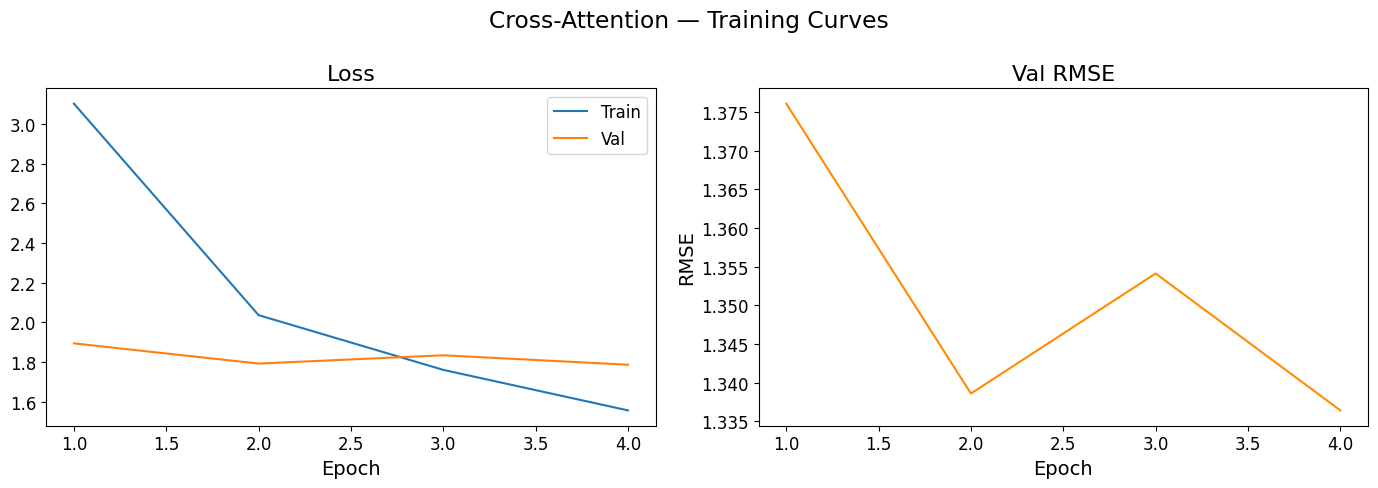

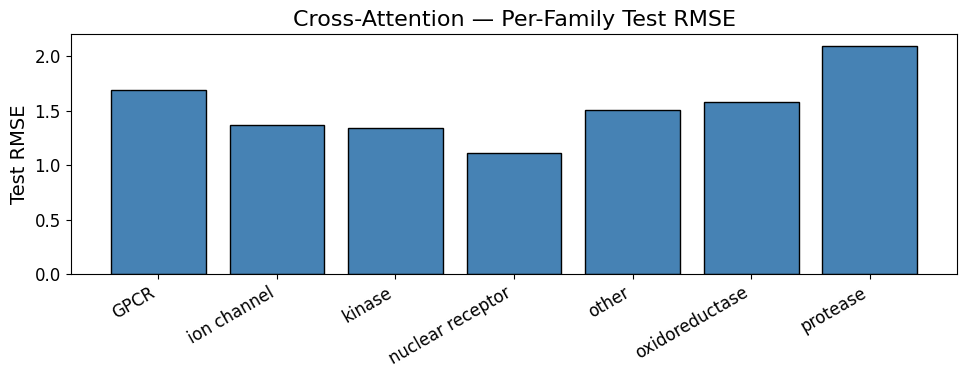

In [ ]:
#===== Load pre-tuned model
old_config = {
    "drug_input_dim": drug_input_dim,
    "prot_input_dim": prot_input_dim,
    "hidden_dim": 32,
    "num_heads": 4,
    "dropout": 0.1,
    "regressor_hidden_dim": 32,
}

old_model = CrossAttentionRegressor(
    drug_input_dim=old_config["drug_input_dim"],
    prot_input_dim=old_config["prot_input_dim"],
    hidden_dim=old_config["hidden_dim"],
    num_heads=old_config["num_heads"],
    dropout=old_config["dropout"],
    regressor_hidden_dim=old_config["regressor_hidden_dim"],
).to(DEVICE)

old_dir_ca = Path("./checkpoints/cross_attention")
best_ckpt_path = old_dir_ca / "best.pt"
old_ckpt = load_checkpoint(best_ckpt_path, old_model, optimizer=None, device=DEVICE)

model.eval()
old_ca_train_df = get_pred_df(old_model, train_loader, DEVICE)
old_ca_val_df = get_pred_df(old_model, val_loader, DEVICE)
old_ca_test_df = get_pred_df(old_model, test_loader, DEVICE)

old_history = old_ckpt["history"]
old_best_history = [
    {
        "epoch": i + 1,
        "train_loss": old_history["train_loss"][i],
        "loss": old_history["val_mse"][i],
        "RMSE": old_history["val_rmse"][i],
        "MAE": old_history["val_mae"][i],
    }
    for i in range(len(old_history["train_loss"]))
]
plot_model_results(
    "Cross-Attention",
    old_best_history,
    old_ca_train_df,
    old_ca_val_df,
    old_ca_test_df
)


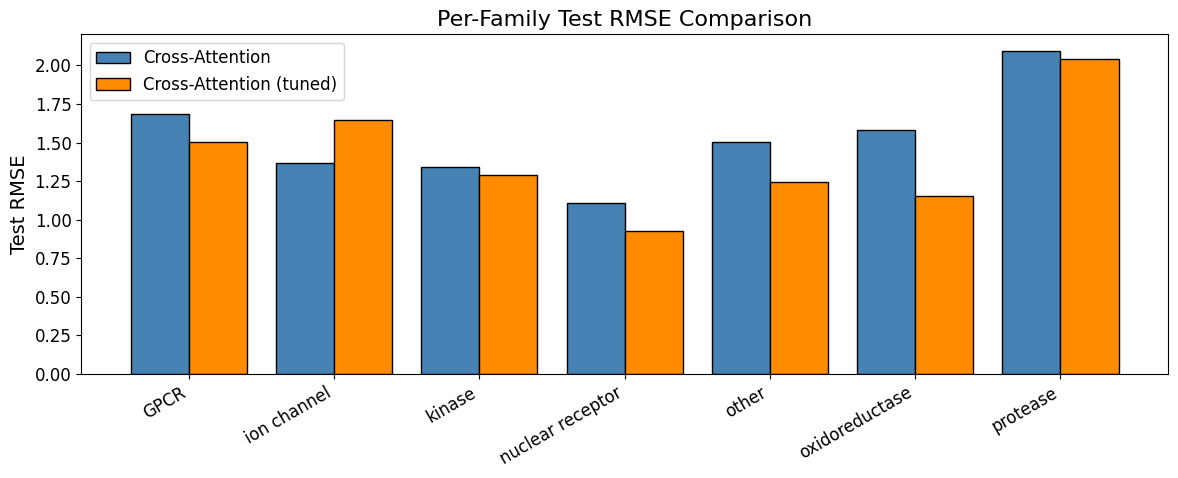

In [ ]:
old_rmse = old_ca_test_df.groupby("family").apply(
    lambda g: np.sqrt(((g["true"] - g["mu"]) ** 2).mean())
)
new_rmse = ca_test_df.groupby("family").apply(
    lambda g: np.sqrt(((g["true"] - g["mu"]) ** 2).mean())
)

families = sorted(set(old_rmse.index) | set(new_rmse.index))
x = np.arange(len(families))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - bar_width / 2, old_rmse.reindex(families).values,
        width=bar_width, color="steelblue", edgecolor="black", label="Cross-Attention")
ax.bar(x + bar_width / 2, new_rmse.reindex(families).values,
        width=bar_width, color="darkorange", edgecolor="black", label="Cross-Attention (tuned)")

ax.set_xticks(x)
ax.set_xticklabels(families, rotation=30, ha="right")
ax.set_ylabel("Test RMSE")
ax.set_title("Per-Family Test RMSE Comparison")
ax.legend()
plt.tight_layout()
plt.show()

#### Cross-Attention performance

- Learning: Previously, validation loss and RMSE were almost entirely flat during training. The latest model shows a somewhat improved journey though still suffers somewhat from overfitting.

- The test-RMSE of the pre-tuned was a trivial improvement over the "always predict mean pKd" baseline, whereas the tuned model now records a substantial improvement (~8.75% lower RMSE).

### 8.4 Hybrid Architecture

The bilinear head captures global multiplicative structure between pooled modality vectors; cross-attention captures local, position-specific interactions over full token sequences. These inductive biases are complementary, and binding can plausibly depend on both. The hybrid runs the two pathways in parallel and concatenates their outputs, testing whether they contribute independent signals.

The model takes both CLS embeddings (for the bilinear pathway) and full token sequences (for the cross-attention pathway), with small additive Gaussian noise (σ = 0.01) on the inputs as regularization. Representations are projected into two hidden spaces with dimension sizes of 128 and 64 for cross-attention and bilinear respectively. The cross-attention pathway uses 4-head attention applied drug-to-protein then protein-to-drug, followed by masked-mean pooling, yielding a 256-dimensional vector. The bilinear pathway produces a 64-dimensional multiplicative interaction. The two outputs are LayerNorm-normalized, concatenated to 320 dimensions, and passed through a feed-forward head (320 → 128 → 1) to produce the scalar pKd prediction.

### 8.4.1 Hybrid Model Architecture

Define the `HybridAffinityModel` combining cross-attention and bilinear pathways. Each pathway operates in a separate hidden space (128-dim for cross-attention, 64-dim for bilinear), and their outputs are LayerNorm-normalized before concatenation.

In [ ]:
class HybridAffinityModel(nn.Module):
    """
    Hybrid model combining:
    1. Cross-attention mechanism for contextual interaction between drug and protein tokens
    2. Bilinear fusion for rich feature interaction
    3. Independent normalization of each pathway before concatenation
    4. Gaussian noise injection on input embeddings during training to prevent memorization
    5. Pathway dropout: randomly zeroes one entire pathway during training to
       prevent the regressor from relying on a single signal source

    Architecture:
    - Path A (Cross-Attention): Separate projections to attn_dim, bidirectional
      cross-attention with post-attention FFN blocks, masked mean pooling
      → output: (B, attn_dim * 2) from concatenated drug + protein pools
    - Path B (Bilinear): Separate projections to bilinear_dim, bilinear
      tensor interaction on pooled representations → output: (B, bilinear_dim)
    - Each pathway is independently LayerNorm'd, then concatenated so the
      regressor can learn how to weight them
    - Regressor input: attn_dim * 2 + bilinear_dim
    """

    def __init__(
        self,
        drug_input_dim: int,
        prot_input_dim: int,
        attn_dim: int = 128,
        bilinear_dim: int = 64,
        num_heads: int = 4,
        dropout: float = 0.3,
        embedding_noise_std: float = 0.1,
        pathway_drop_prob: float = 0.0,
    ):
        super().__init__()

        if attn_dim % num_heads != 0:
            raise ValueError("attn_dim must be divisible by num_heads")

        self.embedding_noise_std = embedding_noise_std
        self.pathway_drop_prob = pathway_drop_prob

        # ============================================================
        # Input projections — separate for each pathway
        # ============================================================
        self.drug_proj_attn = nn.Sequential(
            nn.Linear(drug_input_dim, attn_dim),
            nn.LayerNorm(attn_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.prot_proj_attn = nn.Sequential(
            nn.Linear(prot_input_dim, attn_dim),
            nn.LayerNorm(attn_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.drug_proj_bil = nn.Sequential(
            nn.Linear(drug_input_dim, bilinear_dim),
            nn.LayerNorm(bilinear_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.prot_proj_bil = nn.Sequential(
            nn.Linear(prot_input_dim, bilinear_dim),
            nn.LayerNorm(bilinear_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # ============================================================
        # Cross-attention pathway (Path A)
        # ============================================================
        self.drug_to_prot_attn = nn.MultiheadAttention(
            embed_dim=attn_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.prot_to_drug_attn = nn.MultiheadAttention(
            embed_dim=attn_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        # Post-attention norms
        self.drug_attn_norm = nn.LayerNorm(attn_dim)
        self.prot_attn_norm = nn.LayerNorm(attn_dim)

        # Post-attention FFN blocks (4x expansion, standard transformer)
        self.drug_ffn = nn.Sequential(
            nn.Linear(attn_dim, attn_dim * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(attn_dim * 4, attn_dim),
            nn.Dropout(dropout),
        )
        self.drug_ffn_norm = nn.LayerNorm(attn_dim)

        self.prot_ffn = nn.Sequential(
            nn.Linear(attn_dim, attn_dim * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(attn_dim * 4, attn_dim),
            nn.Dropout(dropout),
        )
        self.prot_ffn_norm = nn.LayerNorm(attn_dim)

        # ============================================================
        # Bilinear fusion pathway (Path B)
        # ============================================================
        self.bilinear = nn.Bilinear(bilinear_dim, bilinear_dim, bilinear_dim)
        self.bilinear_post = nn.Sequential(
            nn.BatchNorm1d(bilinear_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # ============================================================
        # Independent normalization before concatenation
        # ============================================================
        self.attn_path_norm = nn.LayerNorm(attn_dim * 2)
        self.bil_path_norm = nn.LayerNorm(bilinear_dim)

        # ============================================================
        # Final regression head
        # ============================================================
        regressor_input_dim = attn_dim * 2 + bilinear_dim
        self.regressor = nn.Sequential(
            nn.Linear(regressor_input_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    @staticmethod
    def masked_mean(x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        Compute mean pooling over sequence dimension, respecting padding mask.

        Args:
            x: (batch, seq_len, hidden_dim)
            mask: (batch, seq_len) with 1 for valid tokens, 0 for padding

        Returns:
            pooled: (batch, hidden_dim)
        """
        mask_f = mask.unsqueeze(-1).float()  # (B, L, 1)
        summed = (x * mask_f).sum(dim=1)  # (B, H)
        denom = mask_f.sum(dim=1).clamp(min=1e-8)  # (B, 1)
        return summed / denom

    def forward(self, drug_tokens, drug_mask, prot_tokens, prot_mask):
        """
        Forward pass through hybrid model.

        Args:
            drug_tokens: (batch, drug_seq_len, drug_input_dim)
            drug_mask: (batch, drug_seq_len) - 1 for valid, 0 for padding
            prot_tokens: (batch, prot_seq_len, prot_input_dim)
            prot_mask: (batch, prot_seq_len) - 1 for valid, 0 for padding

        Returns:
            pKd_pred: (batch,) scalar predictions
        """
        # ============================================================
        # Gaussian noise on input embeddings (training only)
        # ============================================================
        if self.training and self.embedding_noise_std > 0:
            drug_tokens = (
                drug_tokens + torch.randn_like(drug_tokens) * self.embedding_noise_std
            )
            prot_tokens = (
                prot_tokens + torch.randn_like(prot_tokens) * self.embedding_noise_std
            )

        # ============================================================
        # Step 1: Separate projections for each pathway
        # ============================================================
        d_attn = self.drug_proj_attn(drug_tokens)  # (B, L_d, attn_dim)
        p_attn = self.prot_proj_attn(prot_tokens)  # (B, L_p, attn_dim)

        d_bil = self.drug_proj_bil(drug_tokens)  # (B, L_d, bilinear_dim)
        p_bil = self.prot_proj_bil(prot_tokens)  # (B, L_p, bilinear_dim)

        # Attention masks (True = ignore, False = attend)
        drug_key_padding_mask = drug_mask == 0
        prot_key_padding_mask = prot_mask == 0

        # ============================================================
        # Path A: Cross-attention + FFN (full transformer block)
        # ============================================================
        # Drug attends to protein
        d_attended, _ = self.drug_to_prot_attn(
            query=d_attn,
            key=p_attn,
            value=p_attn,
            key_padding_mask=prot_key_padding_mask,
            need_weights=False,
        )
        d_attn = self.drug_attn_norm(d_attn + d_attended)
        d_attn = self.drug_ffn_norm(d_attn + self.drug_ffn(d_attn))

        # Protein attends to drug
        p_attended, _ = self.prot_to_drug_attn(
            query=p_attn,
            key=d_attn,
            value=d_attn,
            key_padding_mask=drug_key_padding_mask,
            need_weights=False,
        )
        p_attn = self.prot_attn_norm(p_attn + p_attended)
        p_attn = self.prot_ffn_norm(p_attn + self.prot_ffn(p_attn))

        # Pool attention-enriched representations
        d_pool = self.masked_mean(d_attn, drug_mask.bool())  # (B, attn_dim)
        p_pool = self.masked_mean(p_attn, prot_mask.bool())  # (B, attn_dim)

        # ============================================================
        # Path B: Bilinear fusion on pooled representations
        # ============================================================
        d_pool_bil = self.masked_mean(d_bil, drug_mask.bool())  # (B, bilinear_dim)
        p_pool_bil = self.masked_mean(p_bil, prot_mask.bool())  # (B, bilinear_dim)

        bilinear_out = self.bilinear(d_pool_bil, p_pool_bil)  # (B, bilinear_dim)
        bilinear_out = self.bilinear_post(bilinear_out)

        # ============================================================
        # Step 2: Independent normalization + concatenation
        # ============================================================
        attn_signal = torch.cat([d_pool, p_pool], dim=-1)  # (B, attn_dim*2)
        attn_signal = self.attn_path_norm(attn_signal)  # normalize

        bil_signal = self.bil_path_norm(bilinear_out)  # normalize

        # ============================================================
        # Pathway dropout: randomly zero one entire pathway during training
        # to force the regressor to use both signal sources
        # ============================================================
        if self.training and self.pathway_drop_prob > 0:
            r = torch.rand(1).item()
            if r < self.pathway_drop_prob:
                # Drop cross-attention pathway — scale bilinear up to compensate
                attn_signal = torch.zeros_like(attn_signal)
                bil_signal = bil_signal * 2.0
            elif r < 2 * self.pathway_drop_prob:
                # Drop bilinear pathway — scale cross-attention up to compensate
                bil_signal = torch.zeros_like(bil_signal)
                attn_signal = attn_signal * 2.0

        fused = torch.cat(
            [attn_signal, bil_signal], dim=-1
        )  # (B, attn_dim*2 + bilinear_dim)

        # ============================================================
        # Step 3: Final regression to pKd
        # ============================================================
        return self.regressor(fused).squeeze(-1)  # (B,)


### 8.4.2 Datasets and Dataloaders

Configure the hybrid model's data pipeline. A small batch size of 8 (down from 256) was the single largest improvement found during hyperparameter search, reducing validation RMSE from 1.46 to 1.32.

In [ ]:
# Configuration for Hybrid Model
BATCH_SIZE_HYBRID = 8
train_loader_hybrid = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE_HYBRID,
    sampler=train_sampler,
    collate_fn=collate_padded,
    num_workers=2,
    pin_memory=True,
)
val_loader_hybrid = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE_HYBRID,
    shuffle=False,
    collate_fn=collate_padded,
    num_workers=2,
    pin_memory=True,
)
test_loader_hybrid = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE_HYBRID,
    shuffle=False,
    collate_fn=collate_padded,
    num_workers=2,
    pin_memory=True,
)

# Get input dimensions from the data
sample_drug, sample_prot, _, _ = train_ds[0]
drug_input_dim = sample_drug.shape[-1]
prot_input_dim = sample_prot.shape[-1]

model_config = {
    "drug_input_dim": drug_input_dim,
    "prot_input_dim": prot_input_dim,
    "attn_dim": 128,
    "bilinear_dim": 64,
    "num_heads": 4,
    "dropout": 0.3,
    "embedding_noise_std": 0,
    "pathway_drop_prob": 0.15,
    "target_col": "pKd",
    "learning_rate": 3e-4,
    "weight_decay": 1e-3,
}

print(f"Model configuration:")
for k, v in model_config.items():
    print(f"  {k}: {v}")


Model configuration:
  drug_input_dim: 768
  prot_input_dim: 1024
  attn_dim: 128
  bilinear_dim: 64
  num_heads: 4
  dropout: 0.3
  embedding_noise_std: 0
  pathway_drop_prob: 0.15
  target_col: pKd
  learning_rate: 0.0003
  weight_decay: 0.001


In [ ]:
# Instantiate Hybrid Model
hybrid_model = HybridAffinityModel(
    drug_input_dim=model_config["drug_input_dim"],
    prot_input_dim=model_config["prot_input_dim"],
    attn_dim=model_config["attn_dim"],
    bilinear_dim=model_config["bilinear_dim"],
    num_heads=model_config["num_heads"],
    dropout=model_config["dropout"],
    embedding_noise_std=model_config["embedding_noise_std"],
    pathway_drop_prob=model_config["pathway_drop_prob"],
).to(DEVICE)

optimizer = torch.optim.AdamW(
    hybrid_model.parameters(),
    lr=model_config["learning_rate"],
    weight_decay=model_config["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4, min_lr=1e-6
)

print(hybrid_model)
print(f"\nTotal parameters: {sum(p.numel() for p in hybrid_model.parameters()):,}")


HybridAffinityModel(
  (drug_proj_attn): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (prot_proj_attn): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (drug_proj_bil): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (prot_proj_bil): Sequential(
    (0): Linear(in_features=1024, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (drug_to_prot_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_feature

### 8.4.3 Training Function

Define the per-epoch training step using MSE loss on pKd values. Gradient clipping at max-norm 1.0 stabilizes training given the hybrid model's combined parameter space.

In [ ]:
def train_one_epoch_hybrid(model, loader, optimizer, device):
    """
    Train for one epoch on the hybrid model.
    Uses MSE loss for pKd regression.
    """
    model.train()
    total_loss = 0.0
    total_count = 0

    for drug_tokens, drug_mask, prot_tokens, prot_mask, y, _families in tqdm(
        loader, desc="Training", leave=False
    ):
        drug_tokens = drug_tokens.to(device)
        drug_mask = drug_mask.to(device)
        prot_tokens = prot_tokens.to(device)
        prot_mask = prot_mask.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_hat = model(drug_tokens, drug_mask, prot_tokens, prot_mask)
        loss = ((y_hat - y) ** 2).mean()
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = y.shape[0]
        total_loss += loss.item() * bs
        total_count += bs

    return total_loss / max(total_count, 1)


@torch.no_grad()
def evaluate_hybrid(model, loader, device):
    """
    Evaluate the hybrid model on a dataset.
    Returns MSE, RMSE, and MAE metrics.
    """
    model.eval()
    total_loss = 0.0
    total_count = 0
    preds, targets = [], []

    for drug_tokens, drug_mask, prot_tokens, prot_mask, y, _families in tqdm(
        loader, desc="Evaluating", leave=False
    ):
        drug_tokens = drug_tokens.to(device)
        drug_mask = drug_mask.to(device)
        prot_tokens = prot_tokens.to(device)
        prot_mask = prot_mask.to(device)
        y = y.to(device)

        y_hat = model(drug_tokens, drug_mask, prot_tokens, prot_mask)
        mse = ((y_hat - y) ** 2).mean()

        bs = y.shape[0]
        total_loss += mse.item() * bs
        total_count += bs

        preds.append(y_hat.cpu())
        targets.append(y.cpu())

    preds = torch.cat(preds, dim=0).numpy()
    targets = torch.cat(targets, dim=0).numpy()

    mse = total_loss / max(total_count, 1)
    rmse = np.sqrt(mse)
    mae = np.abs(preds - targets).mean()

    return {"mse": mse, "rmse": rmse, "mae": mae}


### 8.4.4 Train and Evaluate Hybrid Model

Train with early stopping on validation loss, retaining the best checkpoint. The hybrid model was highly unstable under hyperparameter tuning and its ~1 hr per-experiment compute cost made automated search infeasible; tuning was therefore manual and coarse. Pathway dropout (p = 0.15) — zeroing one of the two branches per sample and scaling the surviving branch 2× — was the primary regularization win, reducing the validation-to-training loss ratio from 5:1 to 2:1.

In [ ]:
# Training configuration
num_epochs = 50
patience = 10

# Checkpoint paths
latest_ckpt_path = "./checkpoints/hybrid/latest.pt"
best_ckpt_path = "./checkpoints/hybrid/best.pt"

if os.path.exists(best_ckpt_path):
    data = load_checkpoint(
        latest_ckpt_path, hybrid_model, optimizer=None, device=DEVICE
    )
    history = data["history"]
    data = load_checkpoint(best_ckpt_path, hybrid_model, optimizer=None, device=DEVICE)
    print(
        f"Loaded existing best checkpoint from {best_ckpt_path} with best_val_mae={data['best_val_mae']:.4f} at epoch {data['epoch']}."
    )
else:
    # Training history
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_rmse": [],
        "val_mae": [],
    }

    best_val_rmse = float("inf")
    wait = 0
    start_epoch = 1

    # Delete old checkpoints to start fresh
    for p in [latest_ckpt_path, best_ckpt_path]:
        if os.path.exists(p):
            os.remove(p)
            print(f"Removed old checkpoint: {p}")

    print("Starting training from scratch")
    print(f"\nTraining Hybrid Model")
    print(f"Epochs: {num_epochs}, Patience: {patience}")
    print(f"Batch size: {BATCH_SIZE_HYBRID}")
    print("=" * 60)

    torch.cuda.empty_cache()

    early_stopped = False

    for epoch in range(start_epoch, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")

        train_loss = train_one_epoch_hybrid(
            hybrid_model, train_loader_hybrid, optimizer, DEVICE
        )
        val_metrics = evaluate_hybrid(hybrid_model, val_loader_hybrid, DEVICE)

        history["train_loss"].append(float(train_loss))
        history["val_loss"].append(float(val_metrics["mse"]))
        history["val_rmse"].append(float(val_metrics["rmse"]))
        history["val_mae"].append(float(val_metrics["mae"]))

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['mse']:.4f} | "
            f"val_rmse={val_metrics['rmse']:.4f} | val_mae={val_metrics['mae']:.4f} | "
            f"lr={current_lr:.1e}"
        )

        # Step scheduler (ReduceLROnPlateau watches val RMSE)
        scheduler.step(val_metrics["rmse"])

        # Check for improvement (based on val RMSE)
        if val_metrics["rmse"] < best_val_rmse:
            best_val_rmse = val_metrics["rmse"]
            wait = 0
            is_best = True
            print(f"  New best validation RMSE: {best_val_rmse:.4f}")
        else:
            wait += 1
            is_best = False
            print(f"  No improvement. Patience counter: {wait}/{patience}")

        # Early stopping check
        if wait >= patience:
            early_stopped = True
            print(f"\nEarly stopping at epoch {epoch}")

        # Save latest checkpoint
        save_checkpoint(
            path=latest_ckpt_path,
            model=hybrid_model,
            optimizer=optimizer,
            epoch=epoch,
            history=history,
            best_val_mae=best_val_rmse,
            model_config=model_config,
            early_stopped=early_stopped,
        )

        # Save best checkpoint
        if is_best:
            save_checkpoint(
                path=best_ckpt_path,
                model=hybrid_model,
                optimizer=optimizer,
                epoch=epoch,
                history=history,
                best_val_mae=best_val_rmse,
                model_config=model_config,
                early_stopped=False,
            )

        if early_stopped:
            break

    print("\n" + "=" * 60)
    print(f"Training completed!")
    print(f"Best validation RMSE: {best_val_rmse:.4f}")
    best_idx = np.argmin(history["val_rmse"])
    print(f"Best validation MAE:  {history['val_mae'][best_idx]:.4f}")
    print(f"Best model saved to: {best_ckpt_path}")


Loaded existing best checkpoint from ./checkpoints/hybrid/best.pt with best_val_mae=1.3248 at epoch 11.


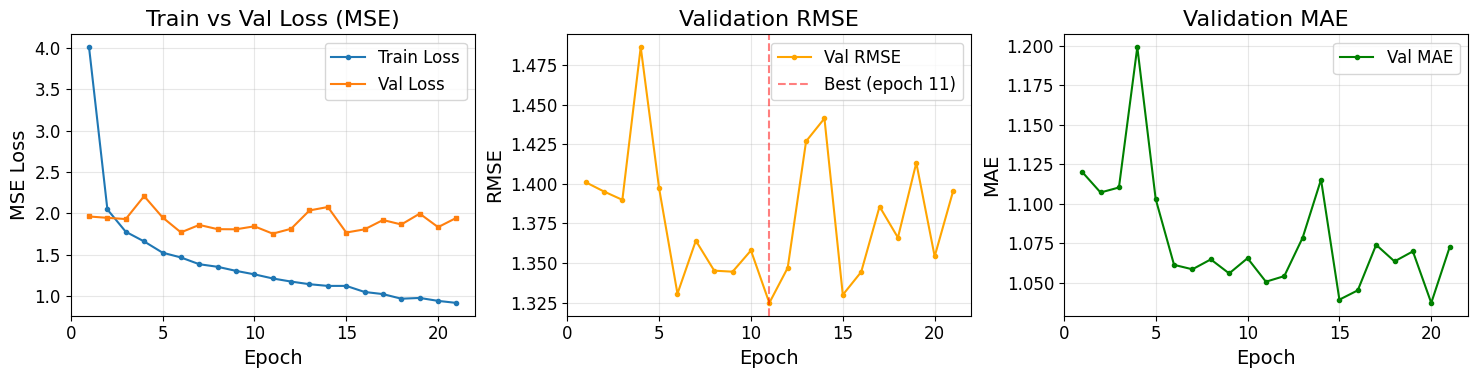


Best Epoch: 11
  Best Val RMSE: 1.3248
  Best Val MAE:  1.0506


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

# Train vs Val Loss (MSE)
axes[0].plot(
    epochs_range, history["train_loss"], label="Train Loss", marker="o", markersize=3
)
axes[0].plot(
    epochs_range, history["val_loss"], label="Val Loss", marker="s", markersize=3
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Train vs Val Loss (MSE)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation RMSE
axes[1].plot(
    epochs_range,
    history["val_rmse"],
    label="Val RMSE",
    color="orange",
    marker="o",
    markersize=3,
)
best_idx = np.argmin(history["val_rmse"])
axes[1].axvline(
    best_idx + 1,
    color="red",
    linestyle="--",
    alpha=0.5,
    label=f"Best (epoch {best_idx + 1})",
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Validation RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Validation MAE
axes[2].plot(
    epochs_range,
    history["val_mae"],
    label="Val MAE",
    color="green",
    marker="o",
    markersize=3,
)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAE")
axes[2].set_title("Validation MAE")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest Epoch: {best_idx + 1}")
print(f"  Best Val RMSE: {history['val_rmse'][best_idx]:.4f}")
print(f"  Best Val MAE:  {history['val_mae'][best_idx]:.4f}")


### 8.4.5 Hybrid Model Performance

Evaluate the best checkpoint on the held-out test set and inspect per-family RMSE. The hybrid achieved a test RMSE of 1.453, the highest among all four fusion heads, despite having the most complex architecture. This suggests that the two pathways do not contribute fully independent signals and that the additional regularization burden outweighs any complementary gain at this data scale.

In [ ]:
# Load best model and evaluate on test set
print(f"Loading best model from {best_ckpt_path}")
load_checkpoint(best_ckpt_path, hybrid_model, optimizer=None, device=DEVICE)

test_metrics = evaluate_hybrid(hybrid_model, test_loader_hybrid, DEVICE)

print("\nTest Set Results:")
print(f"  MSE:  {test_metrics['mse']:.4f}")
print(f"  RMSE: {test_metrics['rmse']:.4f}")
print(f"  MAE:  {test_metrics['mae']:.4f}")


Loading best model from ./checkpoints/hybrid/best.pt



Test Set Results:
  MSE:  2.1100
  RMSE: 1.4526
  MAE:  1.1153


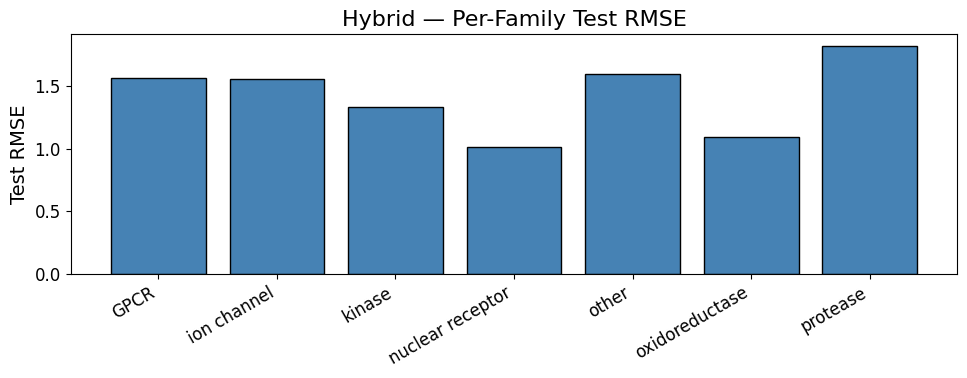

In [ ]:
# get test predictions per protein family
@torch.no_grad()
def get_pred_df_hybrid(model, loader, device):
    """Returns DataFrame: true pKd, predicted mu, sigma (NLL only), protein family."""
    model.eval()
    rows = []
    for drug_tokens, drug_mask, prot_tokens, prot_mask, pkd, family in loader:
        pred = model(
            drug_tokens.to(device),
            drug_mask.to(device),
            prot_tokens.to(device),
            prot_mask.to(device),
        )
        if pred.dim() == 1:
            mu = pred.cpu().numpy()
            sigma = np.full(len(mu), np.nan)
        else:
            mu = pred[:, 0].cpu().numpy()
            sigma = torch.exp(pred[:, 1] / 2).cpu().numpy()
        for i in range(len(mu)):
            rows.append(
                {
                    "true": pkd[i].item(),
                    "mu": mu[i],
                    "sigma": sigma[i],
                    "family": family[i],
                }
            )
    return pd.DataFrame(rows)


hybrid_test_df = get_pred_df_hybrid(hybrid_model, test_loader_hybrid, DEVICE)

rmse_by_fam = (
    hybrid_test_df.groupby("family")
    .apply(lambda g: np.sqrt(((g["true"] - g["mu"]) ** 2).mean()))
    .sort_index()
)
families = rmse_by_fam.index.tolist()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(families, rmse_by_fam.values, color="steelblue", edgecolor="black")
ax.set_xticks(range(len(families)))
ax.set_xticklabels(families, rotation=30, ha="right")
ax.set_ylabel("Test RMSE")
ax.set_title("Hybrid — Per-Family Test RMSE")
plt.tight_layout()
plt.show()

# 9. Summary of Results and Future Directions

## Summary of Results

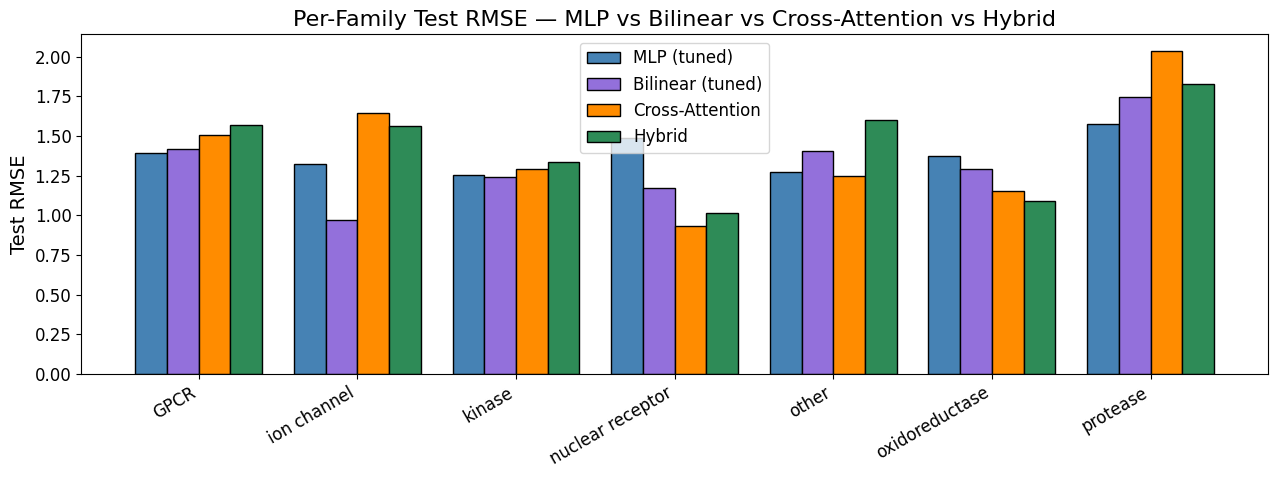

In [ ]:
# Per-family Test RMSE — all four fusion heads side by side (best config for each)
model_dfs = [
    ("MLP (tuned)",          tuned_test_df,     "steelblue"),
    ("Bilinear (tuned)",     bil_tuned_test_df, "mediumpurple"),
    ("Cross-Attention",      ca_test_df,        "darkorange"),
    ("Hybrid",               hybrid_test_df,    "seagreen"),
]

families = sorted(set().union(*[set(df["family"]) for _, df, _ in model_dfs]))


def family_rmse(df, f):
    g = df[df["family"] == f]
    return np.sqrt(((g["true"] - g["mu"]) ** 2).mean()) if len(g) else np.nan


x = np.arange(len(families))
w = 0.8 / len(model_dfs)
offsets = np.linspace(-(len(model_dfs) - 1) / 2, (len(model_dfs) - 1) / 2, len(model_dfs)) * w

fig, ax = plt.subplots(figsize=(13, 5))
for (label, df, color), off in zip(model_dfs, offsets):
    rmse = [family_rmse(df, f) for f in families]
    ax.bar(x + off, rmse, w, label=label, color=color, edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(families, rotation=30, ha="right")
ax.set_ylabel("Test RMSE")
ax.set_title("Per-Family Test RMSE — MLP vs Bilinear vs Cross-Attention vs Hybrid")
ax.legend()
plt.tight_layout()
plt.show()


## 9.1 Performance Comparison Across Fusion Heads

|              | Train RMSE  |             | Val RMSE   |            | Test RMSE  |            |
|--------------|------------:|------------:|-----------:|-----------:|-----------:|-----------:|
|              | **Baseline**| **Tuned**   | **Baseline**| **Tuned** | **Baseline**| **Tuned** |
| Naive        | 1.5364      | —           | 1.5627     | —          | 1.4850     | —          |
| MLP          | 0.7058      | **0.7793**      | 1.3577     | **1.2527**     | 1.3851     | **1.3030** |
| Bilinear     | 0.7403      | 1.2959      | 1.4206     | 1.4024     | 1.3313     | 1.3217     |
| Cross-Attention | 1.0109   | 0.9828           | 1.3364     |1.3504      | 1.4787     | 1.3550      |
| Hybrid       | —           | 1.1017      | —          | 1.3248     | —          | 1.4526     |

*RMSE on train/val/test sets for each fusion architecture, comparing baseline (MS3) to the best post-finetuning configuration. Naive baseline predicts the training-set mean pKd. Lower is better; bold marks the best test RMSE.*


## 9.2 Interpretation

**Test performance was inversely correlated with model complexity.** The MLP, our simplest fusion head, achieved the best test RMSE (1.30), followed by the bilinear (1.32) and hybrid (1.45) models. Neither the bilinear's multiplicative prior nor the hybrid's combined inductive biases offered a clear advantage. All four architectures cluster in a narrow band (1.30–1.45) despite very different inductive biases, and all sit ~2–3× above the inter-lab noise floor of 0.4–0.6 pKd identified during EDA.

**Regularization, not capacity, was the binding constraint.** Across all four hyperparameter searches, the most impactful interventions were uniformly regularization-related — modality dropout for the MLP, increased dropout and LayerNorm for the bilinear, pathway dropout for the hybrid. This pattern suggests that, at the current data scale and embedding choice, gains from richer fusion heads are bounded by generalization rather than expressiveness.

## 9.3 Limitations

- **Frozen encoders.** Neither ProtBERT nor ChemBERTa was pre-trained on a binding-affinity objective, and we did not fine-tune them end-to-end due to GPU memory constraints. More expressive fusion heads cannot recover information the encoders never extracted.
- **Sequence-only representations.** Binding is governed by 3D geometry and electrostatics that 1D sequence embeddings cannot capture.
- **Protein diversity.** Only ~1,000 unique proteins in training and ~200 each in val/test — combined with per-protein partitioning, this leaves the held-out splits statistically noisy.
- **Label noise.** Inter-lab pKd variance of ~0.4–0.6 sets a hard floor on achievable test RMSE.

## 9.4 Future Work

- **Fine-tune the encoders** using parameter-efficient methods (LoRA, adapter layers) that fit within modest GPU budgets.
- **Incorporate 3D structural information** from open sources like AlphaFold, since sequence-only encoders miss binding-relevant geometry.
- **Cross-pollinate the best regularizers.** Modality dropout was the dominant gain in the MLP search but was never tested in the bilinear, cross-attention, or hybrid architectures — the same applies to Mixup and pathway dropout.
- **Acquire a more protein-diverse corpus.** The current protein-family skew biases screening capacity toward already-studied targets and limits the generalization signal in held-out splits.
